<a href="https://colab.research.google.com/github/YaakovKris/DATA_ENGINEERING_NAYA/blob/main/Module_09_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 9 - Introduction to Pandas

Pandas is Python's premier package for handling tabular data. It is built on top of Numpy (which means it provides good performance), adding many features making working with large sheets of data easier. It can be thought of an Excel spreadsheet in code.

Padas main data structure is the ***Data Frame***. A Data Frame (or DF for short) is what holds the table in memory. It supports two indices out-of-the-box: **column indices** (equivalent to column names), and **row indices**. Both indices can be assigned labels, making access requests more readable (compared to using indices).

Another important data structure is the ***Series***. A Series is similar to a vector / array of data, a single column or a single row.

pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool,
built on top of the Python programming language.

[official site](https://pandas.pydata.org/)

In [26]:
import pandas as pd

data_2 = {
    "Age":    [1, 3, 5, 2],
    "Weight": [100, 24, 11, 4],
    "Sound":  ["Moo", "Woof", "OooOoo", "Quack"],
    "Height": [120.5, 60.3, 71.4, 35.9]
}

# Создать DataFrame
df = pd.DataFrame(data_2)

# 1. Показать все возраста
print(df["Age"])

# 2. Показать возраст последних двух строк
print(df["Age"].iloc[-2:])

# 3. Показать Height и Weight строк 0,2,3
print(df.loc[[0, 2, 3], ["Height", "Weight"]])

# 4. Вернуть все числовые столбцы
print(df.select_dtypes(include="number"))

0    1
1    3
2    5
3    2
Name: Age, dtype: int64
2    5
3    2
Name: Age, dtype: int64
   Height  Weight
0   120.5     100
2    71.4      11
3    35.9       4
   Age  Weight  Height
0    1     100   120.5
1    3      24    60.3
2    5      11    71.4
3    2       4    35.9


In [27]:
# Все возраста
df.loc[:, "Age"]

# Возраст последних двух строк
df.iloc[-2:, 0]

# Height и Weight строк 0,2,3
df.loc[[0,2,3], ["Height", "Weight"]]

# Все числовые столбцы
df[["Age", "Weight", "Height"]]

,Age,Weight,Height
0,1,100,120.5
1,3,24,60.3
2,5,11,71.4
3,2,4,35.9


## Setup

In [1]:
# !pip install pandas seaborn plotly

In [2]:
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

In [3]:
import pandas as pd
import seaborn as sns

sns.set(rc={"figure.figsize": (9, 6), "figure.dpi": 120})
sns.set_style("whitegrid")

In [4]:
from pathlib import Path

DATA_DIR = Path("./")
DATA_DIR

PosixPath('.')

In [5]:
!pip install pandas

In [6]:
import pandas as pd

## Learning Goals

- Build a "data engineering mindset" for Pandas work: ingest → validate → transform → aggregate → persist → report
- Load real-world CSV datasets with correct options
- Understand core Pandas objects: Series, DataFrame, and the Index (why it matters)
- Use robust indexing and selection: `[]` vs. `.loc` vs. `.iloc`, boolean masks, safe assignment patterns
- Understand the "operation axis" concept and its impact on aggergations
- Perform common pre-processing operations: missing values, type conversion, string parsing, and basic normalization
- Aggregate data with `groupby` using single/multi-column keys and computed grouping keys; use `agg` vs. `transform` vs. `filter`
- Combine datasets correctly using `merge`, `join`, and `concat`, including key validation and "many-to-one" expectations
- Reshape data for analysis and pipelines using `explode`,` pivot_table`, and `melt` (wide → long for groupby/query friendliness)
- Visualize data for quick EDA using Pandas `.plot`, Seaborn (when available), and a small taste of interactive Plotly
- Integrate Pandas with relational databases: write/read tables and queries via SQLite/SQLAlchemy
- Apply practical "data contract lite" checks (schema, null policy, key uniqueness, value ranges) and produce pipeline-friendly summaries
- Use chunked processing patterns for scalable ingestion and persistence
- Publish outputs in pipeline form (tables + files), with awareness of formats (CSV vs. Parquet, as examples)
- Complete CDE-style exercises that tie together validation, transformation, aggregation, joins, and persistence into a mini batch pipeline

Major updates in Pandas versions:

**Pandas 1.0**
* Dedicated String Type: Introduced an experimental StringDtype to handle text data separately from general object arrays.
* New Extension Arrays: Unlocked the ability to hold missing values (pd.NA) separate from NumPy's standard `np.nan`.

**Pandas 2.0**
* Arrow-Based Backend: Added support for `Apache Arrow` as an internal data engine, drastically speeding up CSV/Excel reading and memory efficiency.
* Nullable Data Types by Default: Expanded support for extension types, allowing you to easily work with booleans, strings, and integers that accurately handle NA values

**Pandas 3.0**
* Default String Type: The dedicated PyArrow-backed string data type replaced object dtype as the default for string parsing, offering 5-10x faster operations.
* Copy-on-Write (CoW): Implemented Copy-on-Write by default, eliminating the dreaded SettingWithCopyWarning and making indexing operations memory-safe.
* Column Expressions (pd.col): Introduced a cleaner pandas.col syntax to reference DataFrame columns, replacing cumbersome lambda functions.
* Datetime Resolution: Switched to microsecond resolution for datetimes and timedeltas to avoid out-of-bounds errors for historical or far-future dates

## Data Engineering mindset: using pandas as a batch data tool

In a Cloud & Data Engineering context, pandas is often used as a **batch processing tool**:

1) **Ingest** data (CSV/JSON/SQL)  
2) **Validate** basic assumptions ("data contract"): schema, keys, nulls, value ranges  
3) **Transform** (clean, normalize, reshape)  
4) **Aggregate** (KPIs, rollups)  
5) **Persist** results (SQL / Parquet / CSV)  
6) **Report** (tables + visuals)

We'll still do exploration, but we'll also adopt a few **pipeline habits**: parameters, logging, and sanity checks.

In [7]:
import logging
from pathlib import Path

In [9]:
# "Pipeline parameters" (to be used later on)
MIN_RATINGS_FOR_LEADERBOARD = 1  # raise this when working with larger datasets
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Logging (common in batch jobs)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("cde")

def log_df(name, frame, key_cols=None):
    """Log 'health info'"""
    print(f"{name}: shape={frame.shape}")
    if key_cols:
        dup = frame.duplicated(subset=key_cols).sum()
        print(f"{name}: duplicates on {key_cols} = {dup}")

## how to approach Pandas questions:

1. load data from CSV
2. clean column name
3. check data and outliers `info`,`describe`,`head`,`tail`,`hist`
4. set / reset index
5. build new columns
6. filter data
7. merge / aggregate
8. visualize

Pandas inherited from ?

* Pandas library technically inherited its underlying data structure from NumPy.
* The foundational `pandas.Series` and `pandas.DataFrame` structures were designed around NumPy arrays `np.array`
* By inheriting from `NumPy`, `Pandas` gained immediate access to fast, compiled `C-extensions` for performing heavy mathematical and matrix operations without relying on slow, native Python loops.


### Numpy

NumPy is the foundational Python library for scientific computing. It introduces the ndarray (N-dimensional array), which stores data of a single type in continuous memory blocks.


What Changed From Python Loops:

* **Vectorization**: You no longer write for loops. Operations are applied to the entire array at once in highly optimized C code.
* **Memory Efficiency**: Python lists store pointers to scattered objects.
NumPy arrays store raw data close together, which maximizes CPU cache efficiency.
* **Homogeneous Types**: Python lists can hold mixed data types, requiring checks on every loop iteration. NumPy forces a single type (dtype), eliminating that overhead.
* *Speed*: Mathematical operations run 10x to 100x faster than native Python loops.


In [13]:
# short numpy example of vectorizing
%%timeit
values = list(range(1,100))
for i in range(len(values)):
  values[i] **= 2

#values[:5]

12.2 µs ± 5.72 µs per loop (mean ± std. dev. of 7 runs, 100000 loops each)


$$f(x) = x^2$$

In [22]:
# short numpy example of vectorizing
%%timeit
import numpy as np

arr = np.arange(1,100)
arr = arr ** 2  # f(x) = x^2


1.95 µs ± 530 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)


In [21]:
import matplotlib.pyplot as plt
plt.plot(arr)

NameError: name 'arr' is not defined

## Series

We'll start with the *Series* data structure. A *Series* is like a Numpy array with an index attached to it. It means that we'll be able to access the data using either the location of the value, or it's index (key).

In [ ]:
ser = pd.Series([3.14, 2.718, 1.618, 3])
ser

,0
0,3.140
1,2.718
2,1.618
3,3.000


The right column is our data, while the left column is the index. To be more specific, a default index, since we haven't specified one explicitly. Don't confuse the default index with position value. If we sorted the Series, the index values would shift their position alongside the values.

In [ ]:
ser = pd.Series([3.14, 2.718, 1.618, 1.414], index=["pi", "e", "golden ratio", "sqrt2"])
ser

,0
pi,3.140
e,2.718
golden ratio,1.618
sqrt2,1.414


### Accessing a Series

We have two methods for that purpose: `.loc` and `.iloc`.

By Position:

In [ ]:
ser.iloc[1]

np.float64(2.718)

In [ ]:
ser.iloc[[1, 0, 3]]

,0
e,2.718
pi,3.140
sqrt2,1.414


In [ ]:
# With iloc, the target index in position range is exclusive.
ser.iloc[1:3]

,0
e,2.718
golden ratio,1.618


By Index:

In [ ]:
ser.loc["sqrt2"]

np.float64(1.414)

In [ ]:
ser.loc[["e", "pi"]]

,0
e,2.718
pi,3.140


In [ ]:
# Note that when index range is used, the target index is INCLUSIVE.
ser.loc["e":"sqrt2"]

,0
e,2.718
golden ratio,1.618
sqrt2,1.414


Unlike Numpy arrays, a Series does not require for all the values to be of the same type.

In [ ]:
ser_2 = pd.Series([123456789, "Sharon", 22.9, True])
ser_2

,0
0,123456789
1,Sharon
2,22.9
3,True


There are many functions that we can apply to Series data. We'll look at some of those when we discuss DataFrames.

## Data Frame

### Creating Manually

In [ ]:
data_1 = [
    [1, 200, "Moo", 120.5],
    [3, 24, "Woof", 60.3],
    [5, 11, "OooOoo", 71.4],
    [2, 4, "Quack", 35.9]
]

In [ ]:
df = pd.DataFrame(data_1)
df

,0,1,2,3
0,1,200,Moo,120.5
1,3,24,Woof,60.3
2,5,11,OooOoo,71.4
3,2,4,Quack,35.9


Setting columns:

* we can set when reading the data

```python
df = pd.DataFrame(data_1, columns=["Age", "Weight", "Sound", "Height"])
```

you can also set after loading

```python
df = pd.DataFrame(data_1)
df.columns = ["Age", "Weight", "Sound", "Height"]
```

In [ ]:
df = pd.DataFrame(data_1, columns=["Age", "Weight", "Sound", "Height"])
df

,Age,Weight,Sound,Height
0,1,200,Moo,120.5
1,3,24,Woof,60.3
2,5,11,OooOoo,71.4
3,2,4,Quack,35.9


In [ ]:
data_2 = {
    "Age":    [1, 3, 5, 2],
    "Weight": [100, 24, 11, 4],
    "Sound":  ["Moo", "Woof", "OooOoo", "Quack"],
    "Height": [120.5, 60.3, 71.4, 35.9]
}

In [ ]:
animals = pd.DataFrame(data_2)
animals

,Age,Weight,Sound,Height
0,1,100,Moo,120.5
1,3,24,Woof,60.3
2,5,11,OooOoo,71.4
3,2,4,Quack,35.9


In [ ]:
df = pd.DataFrame.from_dict(data_2)
df

In [ ]:
data = [
        [1,100,'m',120.5],
        [3,24,'woof',60.3]
        ]

df2 = pd.DataFrame(data, columns=['Weight', 'Sound', 'Height', 'Age'])
df2.columns = ['Weight', 'Sound', 'Height', 'Age']
df2

In [ ]:
df = pd.DataFrame({
    "Weight": pd.Series([100, 24, 11], index=["Cow", "Dog", "Monkey"]),
    "Sound":  pd.Series(["Woof", "OooOoo", "Quack", "Moo"], index=["Dog", "Monkey", "Duck", "Cow"]),
    "Height": pd.Series([120.5, 60.3], index=["Cow", "Dog"]),
    "Age":    pd.Series([1, 3, 5, 2], index=["Cow", "Dog", "Monkey", "Duck"]),
})
df

In [ ]:
df

### From an Existing Data Source

There are quite a few options to populate a Data Frame from an external data source, among which:
* `pd.read_csv`
* `pd.read_excel`
* `pd.read_clipboard`
* `pd.read_json`
* `pd.read_sql`
* Many more...

Loading a CSV file is a common option.
<br/>
Note that the CSV file does not necessarily have to reside on local storage, specifying a URL from which the CSV file can be loaded is fine too.

In [ ]:
pd.read_csv?

In [ ]:
df = pd.read_csv(DATA_DIR / "so2019_survey_results_short.CLEAN.csv",  header=0)
df.head(10)


,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,<500,40.0,57060.0,C++
5,United Kingdom,26.0,Man,3,<500,40.0,455352.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;T...
6,Australia,29.0,Man,2,<100,45.0,65277.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...
7,Brazil,31.0,Man,13,<500,8.0,31140.0,C#;HTML/CSS;Java;JavaScript;SQL;TypeScript
8,Lithuania,38.0,Man,4,"<5,000",140.0,41244.0,Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...
9,United States,47.0,Man,18,">10,000",40.0,103000.0,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...


In [ ]:
original_df = df.copy() # why? when developing, so we wont wait for the entire data to load if we break something along the way

## We interrupt this broadcast...

### CDE sanity checks (data contract *lite*)

When working with real-world data, it's worth doing a few quick checks **immediately after ingest**:

- What is the **shape** (*rows* × *columns*)?
- Do we have an obvious **primary key**? Is it unique?
- What is the **null profile** (which columns are mostly missing)?
- Rough **memory footprint** (is this even safe to handle in-memory)?
- Do the **value ranges** look plausible?

> ❗ **Important**: These checks are not "nice to have" in data engineering - they prevent silent downstream bugs.

In [ ]:
# Basic dataset health signals
log_df("SO2019", df, key_cols=["ResponseId"] if "ResponseId" in df.columns else None)

First thing first. Before anything else, the first time you load your data, you should take a bird's eye view of the data, before getting intimate with it. It will give you a sense of the data's quality (or lack of it) and preliminary area to be inspected once you delve deeper.

Note the `Non-Null Count` and `Dtype` columns. The former lets you know how many non-null values are per given column. The latter states the column's datatype. The datatype is determined automatically by Pandas (after all, CSV and JSON files are textual with no explicit type specifications). Sometimes, Panda's fails to properly detect the right datatype for a column. In other cases, a numeric column may include a single string value, stringify-ing the whole columns.

Later on, we'll see other approaches to detecting and handling missing values.

In [ ]:
# DateFrame metadata summary
df.info(memory_usage='deep')

In [ ]:
df.head()

In [ ]:
df.tail()

In [ ]:
df.sample(10)

> Why would you prefer `sample` to `head` and `tail` when first inspecting a DataFrame?

In [ ]:
# Basic descriptive statistics. Note the min and max values
df.describe()

,Age,YearsCodePro,WorkWeekHrs,ConvertedComp
count,51582.000000,51582.000000,51582.000000,5.158200e+04
mean,31.448180,8.053817,41.996582,1.271387e+05
std,8.111043,7.185080,35.896054,2.832771e+05
min,1.000000,1.000000,1.000000,0.000000e+00
25%,26.000000,3.000000,40.000000,2.623200e+04
50%,30.000000,6.000000,40.000000,5.728700e+04
75%,35.000000,11.000000,43.000000,1.000000e+05
max,99.000000,50.000000,4850.000000,2.000000e+06


<Axes: >

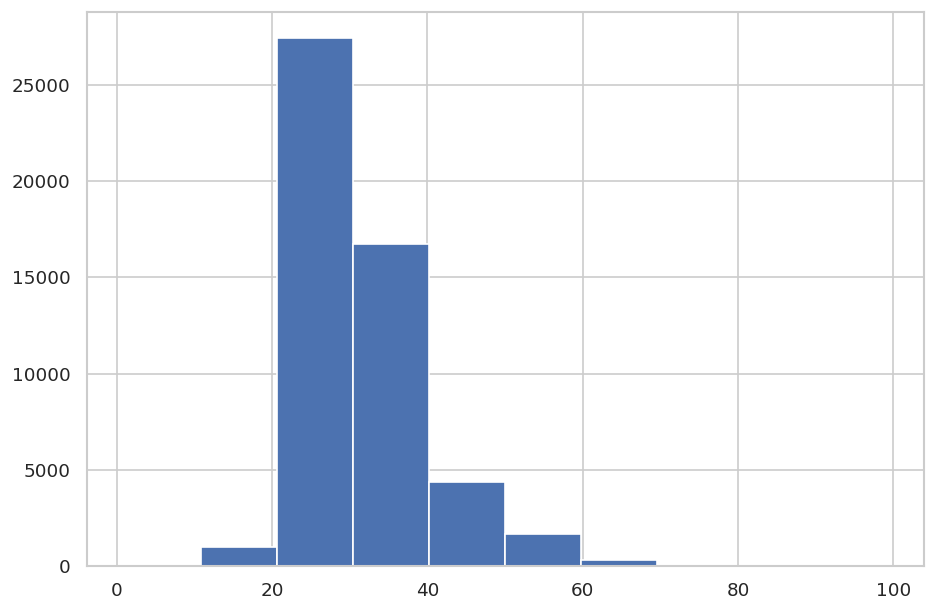

In [ ]:
df['Age'].hist()

In [ ]:
df.describe(include="object")  # include="all" / "object" / "number"

,Country,Gender,OrgSize,LanguageWorkedWith
count,51582,51582,42029,51427
unique,159,7,8,13348
top,United States,Man,<100,C#;HTML/CSS;JavaScript;SQL
freq,13774,47499,11357,999


## Data Frame's Metadata

In [ ]:
# Dimensions (rows, columns), similarly to Numpy
df.shape

(51582, 8)

In [ ]:
# Columns index
df.columns

Index(['Country', 'Age', 'Gender', 'YearsCodePro', 'OrgSize', 'WorkWeekHrs',
       'ConvertedComp', 'LanguageWorkedWith'],
      dtype='object')

In [ ]:
# Rows index
df.index

RangeIndex(start=0, stop=51582, step=1)

In [ ]:
# Both indices
df.axes

[RangeIndex(start=0, stop=51582, step=1),
 Index(['Country', 'Age', 'Gender', 'YearsCodePro', 'OrgSize', 'WorkWeekHrs',
        'ConvertedComp', 'LanguageWorkedWith'],
       dtype='object')]

In [ ]:
# Column data types
df.dtypes

,0
Country,object
Age,float64
Gender,object
YearsCodePro,int64
OrgSize,object
WorkWeekHrs,float64
ConvertedComp,float64
LanguageWorkedWith,object


In [ ]:
# Number of rows (in addition to .shape and .info)
len(df)

51582

In [16]:
!pip install -U ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.9 MB/s eta 0:00:00


In [24]:
from ydata_profiling import ProfileReport

profile = df.profile_report(title='Pandas Profiling Report')
profile.to_notebook_iframe()

NameError: name 'df' is not defined

In [23]:
from ydata_profiling import ProfileReport

In [ ]:
# !pip install -U ydata-profiling
# # restart
# import pandas as pd
from ydata_profiling import ProfileReport

# df = pd.read_csv('/content/diamonds.csv')

profile = df.profile_report(title='Pandas Profiling Report')
profile.to_notebook_iframe()

profile = ProfileReport(df, title='Pandas Profiling Report', html={'style':{'full_width':True}})
profile.to_file("output_report.html")

## Accessing a Data Frame

There are multiple methods using which we could extract data from a DF. The choice of method depends on what it is we are trying to do: process a column? Extract rows by position? Etc.

### By Column

Using square brackets indexing syntax, we can specify one or more columns to be fetched from the original DF.
<br/>
If we specify only one column, we'll end with a **Series** object. If we specify more than one column, we'll get a DF.

Many of the operations we can performs on a Data Frame can be performed on a Series.

In [ ]:
df["Age"]

,Age
0,28.0
1,22.0
2,23.0
3,28.0
4,31.0
...,...
51577,48.0
51578,26.0
51579,34.0
51580,37.0


For convenience, pandas allows us to use ``.`` notation to access columns instead of specifying it's name in brackets, for as long as the column's name does not include any spaces.

In [ ]:
df.Age    # Same as above

In [ ]:
df[["Age", "YearsCodePro"]]     # Fetches multiple columns. The order of columns is arbitrary.

# select age,yearsc from df

### By Position

Lookup rows and columns based on their relative position in the data set.

In [ ]:
df.iloc[[1, 3, 4]]

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
1,United States,22.0,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++


Looking at the next example, can you spot the difference in behavior compared to Numpy?

In [ ]:
#         rows      cols
df.iloc[[1, 3, 4], [0, -1]]

,Country,LanguageWorkedWith
1,United States,C;C++;C#;Python;SQL
3,United States,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,C++


In [ ]:
df.head(2)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Man,1,NaN,40.0,8820.0,HTML/CSS
1,United States,22.0,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL


In [ ]:
df.iloc[row, columns]

# df.iloc[0,5]
# df.iloc[0:5,12:18]
# df.iloc[[1,2,3], [0,-1,12]]



In [ ]:
df.iloc[2:10, 0:3]

,Country,Age,Gender
2,New Zealand,23.0,Man
3,United States,28.0,Man
4,Germany,31.0,Man
5,United Kingdom,26.0,Man
6,Australia,29.0,Man
7,Brazil,31.0,Man
8,Lithuania,38.0,Man
9,United States,47.0,Man


Note that when only a single "row" of values is extracted, a Series object is returned.

In [ ]:
df.iloc[2]

,2
Country,New Zealand
Age,23.0
Gender,Man
YearsCodePro,4
OrgSize,<20
WorkWeekHrs,32.0
ConvertedComp,95179.0
LanguageWorkedWith,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...


### Q IN CLASS

```python
data_2 = {
    "Age":    [1, 3, 5, 2],
    "Weight": [100, 24, 11, 4],
    "Sound":  ["Moo", "Woof", "OooOoo", "Quack"],
    "Height": [120.5, 60.3, 71.4, 35.9]
}
```
1. לייצר דאטהפריים
2. להציג את כל הגילאים
3. להציג את הגיל של 2 השורות האחרונות
4. להציג את הגובה והמשקל של שורות 0,2,3
5. החזירו את כל העמודות המספריות


In [ ]:
#@title Solution

#1
animal = pd.DataFrame(data_2)
animal.columns = animal.columns.str.lower()

#2
animal['age']
animal.age
animal.iloc[:, 0]
animal.loc[:, 'age'] # update

target_columns = ['age']
animal[target_columns]


#3
animal.iloc[-2: , 0]
animal['age'].tail(2)

#4
animal.loc[[0,2,3], ['height','weight']]
animal.iloc[[0,2,3] , [1,-1]]

#5
animal[['age','weight','height']]
animal.select_dtypes('number')
#animal.info()

,age,weight,height
0,1,100,120.5
1,3,24,60.3
2,5,11,71.4
3,2,4,35.9


In [ ]:
L = ['sale_id','att_1','att_2','att_3','sales_fy_26', 'sales_fy_25']

['sale_id']  + list(filter(lambda x: 'att_' in x , L))

['sale_id', 'att_1', 'att_2', 'att_3']

### By Index / Label

Fteching by label relies on the labels assigned to the rows and columns (either explicitly or implicitly) to access the data using using the indices.

By default (and before any manipulations are done on the DF), row labels are simply their relative location from the top (i.e., an integer sequence).

In [ ]:
df = pd.read_csv(DATA_DIR / "so2019_survey_results_short.CLEAN.csv",na_values=['<500'],  header=0)
df.head(10)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Man,1,NaN,40.0,8820.0,HTML/CSS
1,United States,22.0,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++
5,United Kingdom,26.0,Man,3,NaN,40.0,455352.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;T...
6,Australia,29.0,Man,2,<100,45.0,65277.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...
7,Brazil,31.0,Man,13,NaN,8.0,31140.0,C#;HTML/CSS;Java;JavaScript;SQL;TypeScript
8,Lithuania,38.0,Man,4,"<5,000",140.0,41244.0,Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...
9,United States,47.0,Man,18,">10,000",40.0,103000.0,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...


In [ ]:
# np.NaN -> Not A Number (Null numeric)
# None -> NULL
# NoT
# NoD
# DBNull
df.head()


,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Man,1,NaN,40.0,8820.0,HTML/CSS
1,United States,22.0,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++


We can turn any of the colums into our new row index and use it's values as labels.

In [ ]:
df.set_index("Age", inplace=True)
df.head()

,Country,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
Age,,,,,,,
28.0,Thailand,Man,1,NaN,40.0,8820.0,HTML/CSS
22.0,United States,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
23.0,New Zealand,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
28.0,United States,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
31.0,Germany,Man,2,NaN,40.0,57060.0,C++


Now, we can better appreciate fetching by index:

In [ ]:
df.index.unique()[:3]

Index([28.0, 22.0, 23.0], dtype='float64', name='Age')

In [ ]:
example_ages = df.index.unique()[:3]
print(example_ages)

df.loc[example_ages]

Index([28.0, 22.0, 23.0], dtype='float64', name='Age')


,Country,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
Age,,,,,,,
28.0,Thailand,Man,1,NaN,40.0,8820.0,HTML/CSS
28.0,United States,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
28.0,Switzerland,Man,3,"<5,000",36.0,90417.0,NaN
28.0,United States,Woman,5,<100,40.0,135000.0,HTML/CSS;JavaScript;TypeScript
28.0,Austria,Woman,1,<20,385.0,38496.0,HTML/CSS;Java;JavaScript;PHP;Python;SQL
...,...,...,...,...,...,...,...
23.0,United Kingdom,Man,3,<100,40.0,49133.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;S...
23.0,United States,Woman,1,<1000,40.0,68000.0,JavaScript;Ruby
23.0,Ukraine,Man,3,self-employed,40.0,25200.0,HTML/CSS;JavaScript;Python;Swift;TypeScript


In [ ]:
df.loc[example_ages, ["YearsCodePro", "ConvertedComp"]]

,YearsCodePro,ConvertedComp
Age,,
28.0,1,8820.0
28.0,8,90000.0
28.0,3,90417.0
28.0,5,135000.0
28.0,1,38496.0
...,...,...
23.0,3,49133.0
23.0,1,68000.0
23.0,3,25200.0


Keep in mind that index values don't have to be unique (e.g., there can be multiple respondents aged 33).
<br/>
However, when index values are not unique, slicing does not work!

In [ ]:
# df.loc[22:25, ["YearsCodePro", "ConvertedComp"]]

Slicing works for column index values as well. Can be useful when we have a large number of columns (e.g., 365 day-of-year columns).

In [ ]:
df.head(0)

,Country,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
Age,,,,,,,


In [ ]:
df.loc[:, "YearsCodePro":"ConvertedComp"]

,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp
Age,,,,
28.0,1,NaN,40.00,8820.0
22.0,1,NaN,80.00,61000.0
23.0,4,<20,32.00,95179.0
28.0,8,<20,40.00,90000.0
31.0,2,NaN,40.00,57060.0
...,...,...,...,...
48.0,28,<1000,45.00,2000000.0
26.0,3,<100,40.00,130000.0
34.0,7,<100,37.75,82488.0


> **Note:** when dealing with indexes, slicing range is *inclusive* (up to and including the target index value).

Let's reset our row index to it's default integer sequence for the rest of this tutorial:

In [ ]:
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Man,1,NaN,40.0,8820.0,HTML/CSS
1,United States,22.0,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++


In [ ]:
df.set_index('Age', inplace=False) # return copy


df.set_index('Age', inplace=True) # overwrite

,Country,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
Age,,,,,,,
28.0,Thailand,Man,1,NaN,40.00,8820.0,HTML/CSS
22.0,United States,Man,1,NaN,80.00,61000.0,C;C++;C#;Python;SQL
23.0,New Zealand,Man,4,<20,32.00,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
28.0,United States,Man,8,<20,40.00,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
31.0,Germany,Man,2,NaN,40.00,57060.0,C++
...,...,...,...,...,...,...,...
48.0,United States,Man,28,<1000,45.00,2000000.0,Bash/Shell/PowerShell;C;Clojure;HTML/CSS;Java;...
26.0,United States,Man,3,<100,40.00,130000.0,HTML/CSS;JavaScript;Scala;TypeScript
34.0,Finland,Man,7,<100,37.75,82488.0,Bash/Shell/PowerShell;C++;Python


In [ ]:
df.drop(columns=['Age','Gender'], inplace=False)

,Country,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,1,NaN,40.00,8820.0,HTML/CSS
1,United States,1,NaN,80.00,61000.0,C;C++;C#;Python;SQL
2,New Zealand,4,<20,32.00,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,8,<20,40.00,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,2,NaN,40.00,57060.0,C++
...,...,...,...,...,...,...
51577,United States,28,<1000,45.00,2000000.0,Bash/Shell/PowerShell;C;Clojure;HTML/CSS;Java;...
51578,United States,3,<100,40.00,130000.0,HTML/CSS;JavaScript;Scala;TypeScript
51579,Finland,7,<100,37.75,82488.0,Bash/Shell/PowerShell;C++;Python
51580,Austria,9,NaN,39.00,68745.0,Bash/Shell/PowerShell;Go;HTML/CSS;Java;JavaScr...


In [ ]:
df.reset_index(inplace=False)
#df.tail()

,index,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,0,Thailand,28.0,Man,1,NaN,40.00,8820.0,HTML/CSS
1,1,United States,22.0,Man,1,NaN,80.00,61000.0,C;C++;C#;Python;SQL
2,2,New Zealand,23.0,Man,4,<20,32.00,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,3,United States,28.0,Man,8,<20,40.00,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,4,Germany,31.0,Man,2,NaN,40.00,57060.0,C++
...,...,...,...,...,...,...,...,...,...
51577,51577,United States,48.0,Man,28,<1000,45.00,2000000.0,Bash/Shell/PowerShell;C;Clojure;HTML/CSS;Java;...
51578,51578,United States,26.0,Man,3,<100,40.00,130000.0,HTML/CSS;JavaScript;Scala;TypeScript
51579,51579,Finland,34.0,Man,7,<100,37.75,82488.0,Bash/Shell/PowerShell;C++;Python
51580,51580,Austria,37.0,Man,9,NaN,39.00,68745.0,Bash/Shell/PowerShell;Go;HTML/CSS;Java;JavaScr...


In [ ]:
df.sort_values('Country').reset_index(drop=True)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Afghanistan,24.0,Man,1,<10,50.0,1596.0,HTML/CSS;Java;PHP;SQL
1,Afghanistan,26.0,Man,2,">10,000",40.0,17556.0,Assembly;C;C++;HTML/CSS;Java;PHP;SQL
2,Afghanistan,24.0,Man,2,NaN,45.0,7980.0,C#;HTML/CSS;Java;JavaScript;PHP;TypeScript
3,Afghanistan,26.0,Man,1,NaN,49.0,19152.0,HTML/CSS;JavaScript;PHP;SQL;TypeScript
4,Afghanistan,26.0,Man,6,<10,30.0,14364.0,HTML/CSS;JavaScript;PHP
...,...,...,...,...,...,...,...,...
51577,Zimbabwe,30.0,Man,2,"<5,000",40.0,12000.0,C#;HTML/CSS;VBA
51578,Zimbabwe,35.0,Man,4,<20,50.0,42000.0,C#;HTML/CSS;Java;JavaScript;Python;SQL;TypeScript
51579,Zimbabwe,41.0,Man,8,<1000,48.0,30000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
51580,Zimbabwe,29.0,Man,7,<20,45.0,24000.0,HTML/CSS;Java;JavaScript;PHP;SQL


In [ ]:
animal

,age,weight,sound,height
0,1,100,Moo,120.5
1,3,24,Woof,60.3
2,5,11,OooOoo,71.4
3,2,4,Quack,35.9


In [ ]:
bool_mask = [True,True,False,False]
animal[bool_mask]

,age,weight,sound,height
0,1,100,Moo,120.5
1,3,24,Woof,60.3


In [ ]:
animal['weight'] > 20
# [True,True,False,False]

,weight
0,True
1,True
2,False
3,False


In [ ]:
f = (animal.weight > 20)

animal[f]

,age,weight,sound,height
0,1,100,Moo,120.5
1,3,24,Woof,60.3


### By Boolean Masks

Here again, pandas follows numpy's lead and use a nearly identical syntax:

In [ ]:
df[df.Age > 70]

In [ ]:
#loc

df.loc[0, 'age']
df.loc[:0, 'age':'counrty']
df.loc[[0,5,9],['age','yearcodepro']]

df.loc[[True,False],['age','yearcodepro']]
df.loc[df.gender=='woman',['age','yearcodepro']]

In [ ]:
# Remember: whenever using complex conditional, make sure to wrap each condition in parentheses (same as with Numpy).

# ((df.Gender == "Woman") & (df["YearsCodePro"] >= 40)) | (df["WorkWeekHrs"] < 45)

f = (df.Gender == "Woman") & (df["YearsCodePro"] >= 40)

df[f]
# select * from  where gender = 'woman' and yearcode >= 40


# select Country, Age from df
# where gender = 'woman' and yearcode >= 40

df.loc[f, ['Country','Age']]


,Country,Age
18,United States,35.0
42,Philippines,21.0
45,India,27.0
52,China,26.0
59,Canada,39.0
...,...,...
51493,Germany,26.0
51497,United States,24.0
51500,United States,30.0
51504,United States,30.0


### Queries

In [ ]:
# Not that common, but may appeal to some...
f = 'Age > 50 and WorkWeekHrs > 45 and YearsCodePro in (29,37,25)'
df.query(f)

In [ ]:
animal['animal'] = 'unknow'
animal['bmi'] = animal['height'] / animal['weight']
animal

,age,weight,sound,height,animal,bmi
0,1,100,Moo,120.5,unknow,1.205000
1,3,24,Woof,60.3,unknow,2.512500
2,5,11,OooOoo,71.4,unknow,6.490909
3,2,4,Quack,35.9,unknow,8.975000


## Q in Class

use the animal df

```python
data_2 = {
    "Age":    [1, 3, 5, 2],
    "Weight": [100, 24, 11, 4],
    "Sound":  ["Moo", "Woof", "OooOoo", "Quack"],
    "Height": [120.5, 60.3, 71.4, 35.9]
}
```

1. 1- הציגו את כל העמודות עבור מי שמשקלו מעל 20
2. 2-הציגו את כל העמודות עבור מי שמשקלו מעל 20 וגם הגובה גדול מ60
3. 3-צרו עמודה חדשה בשם BMI וחלקו את המשקל בגובה


In [ ]:
#@title Solution

animal = pd.DataFrame( {
    "Age":    [1, 3, 5, 2],
    "Weight": [100, 24, 11, 4],
    "Sound":  ["Moo", "Woof", "OooOoo", "Quack"],
    "Height": [120.5, 60.3, 71.4, 35.9]
})

#1
animal.query("Weight > 20")

#2

#df[X] ->search columns

#df.loc[X] -> search rows
#df.iloc[X] -> search rows
#df.loc[X, :] -> search rows
#df.loc[:, X] -> all columns
#df.loc[Y, X] -> search rows and columns

# f = df[Weight > 20][age]
#animal.loc[f]

animal.loc[(animal.Weight > 20) & (animal.Height > 60)]
animal.query("Weight > 20 and Height > 60")

#3
animal['BMI'] = animal.Weight / animal.Height
animal
animal.eval("BMI = Weight / Height")

,Age,Weight,Sound,Height,BMI
0,1,100,Moo,120.5,0.829876
1,3,24,Woof,60.3,0.398010
2,5,11,OooOoo,71.4,0.154062
3,2,4,Quack,35.9,0.111421


In [ ]:
f = () & ()
cols = []

animal.loc[f, cols]

,Age
0,1
1,3


In [ ]:
%%timeit
animal['BMI'] = animal.Weight / animal.Height

252 µs ± 69.8 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
%%timeit
animal.eval("BMI = Weight / Height")

3.38 ms ± 682 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
# loc[ROW, COLUMNS]

df.loc[0, 'Age']

df.loc[0:5, ['Age','ID','Weight']]

df.loc[:, ['Age','ID','Weight']]

# df.loc[]
# df.iloc[]

df.iloc[0:5, [0,7,-1]]

df.iloc[:, :-5]

# filter

# df.loc[filter, columns]
# read / write
f = (df['Age'] > 0) & (df['Age'] <= 20)
df.loc[f, ['Age','ID','Weight']]

# df.query("")
# read only
df.query("Age > 0 and Age <= 20")



# update city where age > 5

df.loc[df['Age'] > 5 , 'City'] = 'Tel-Aviv'

update df
set City = 'tel-aviv'
where age > 5


In [ ]:
new_input = ['unk']

target = df.loc[:1, 'Gender']

(len(target) // len(new_input)) * new_input

['unk', 'unk']

In [ ]:
# big nono!
for i in range(len(df)):
  df.iloc[i, 0] = L[i]

In [ ]:
df.loc[:1, 'Gender'] = ['unknown']

In [ ]:
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++


## Assignments

Adding a new column is as simple as specifying a new column name in brackets, and assigning it values:

In [ ]:
df["YearsCodeAgePct"] = df.YearsCodePro / df.Age
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,YearsCodeAgePct
0,Thailand,28.0,Man,1,NaN,40.0,8820.0,HTML/CSS,0.035714
1,United States,22.0,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,0.045455
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,0.173913
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,0.285714
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++,0.064516


If we wanted to change a specific value in a specific row and column:

In [ ]:
df.loc[0, "Gender"] = "Woman"    # for single values, same as: df.at[0, "Gender"] = "Woman"
df.head()
# Note: "fancy indexing" assignments work as well.

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Woman,1,NaN,40.0,8820.0,HTML/CSS
1,United States,22.0,Man,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++


<hr/>

### ***Important:*** Modifying Data using a Boolean Mask - The Golden Rule
When attempting to assign values to a subset of a DataFrame, **always** use the `loc` method instead of chaining square brackets.

**Instead of this (Chained Assignment):**
`df[df.Age <= 15]["YearsCodePro"] = 0`

**Do this:**
`df.loc[df.Age <= 15, "YearsCodePro"] = 0`

Why is this so important? The reason depends on which version of Pandas you are using.ץץ

#### 📌 If you are using Pandas 2.x (or earlier)
In older versions of Pandas, the chained operation (`df[...][...] = ...`) happens in two distinct steps: fetching the sliced DataFrame, and then making the assignment.

Pandas cannot guarantee in advance whether the intermediate slice fetched will be a *view* of the source data (a reference) or a completely new *copy*. If a copy is returned, the assignment is made on the copy and is immediately lost, having no effect on your original source data. This ambiguity is what triggers the infamous `SettingWithCopyWarning`. Avoiding chaining by using `loc` performs the operation in a single step, guaranteeing the assignment is carried out on the intended DataFrame.

**Working with intermediate variables in 2.x:**
Often, you will want to narrow down a DataFrame earlier in your code, assign it to a new variable, and modify it later. To avoid warnings and ensure you don't accidentally modify the original data, you must explicitly create a copy:
```python
# Creating an explicit copy is necessary in Pandas 2.x
df_young = df[df.Age <= 15].copy()

# ... later on ...
df_young.loc[:, "YearsCodePro"] = 0
```
👉 [For more details on the 2.x behavior, see here](https://www.datacamp.com/tutorial/settingwithcopywarning-pandas)

#### 📌 If you are using Pandas 3.x (or Pandas 2.x with Copy-on-Write enabled)
In Pandas 3.0, a massive structural change called **Copy-on-Write (CoW)** was made the default behavior. The `SettingWithCopyWarning` is gone, and the rules are now strict: *any* DataFrame derived from another behaves as a completely separate copy.

Because of this, chained assignment (`df[df.Age <= 15]["YearsCodePro"] = 0`) will strictly attempt to modify a temporary copy that gets thrown away. To prevent silent failures, Pandas 3.x will actively stop you and raise a `ChainedAssignmentError`. You **must** use `loc` to modify the original DataFrame.

**Working with intermediate variables in 3.x:**
Thanks to Copy-on-Write, explicitly typing `.copy()` is now obsolete! Slices are evaluated lazily. You can simply assign the slice to a new variable:
```python
# No .copy() needed in Pandas 3.x!
df_young = df[df.Age <= 15]

# ... later on ...
df_young.loc[:, "YearsCodePro"] = 0
```
Because of CoW, `df_young` acts as an independent object. Modifying it will not alter the original `df`. Pandas will implicitly handle copying the underlying data behind the scenes exactly when you make the assignment, keeping your code clean and highly memory-efficient.

👉 [For more details on Copy-on-Write, see the official Pandas documentation](https://pandas.pydata.org/docs/user_guide/copy_on_write.html)
<hr/>

HERE STOP

In [ ]:
copy_df = df.copy()

In [ ]:
copy_df.set_index('Gender', inplace=True)

In [ ]:
copy_df  =copy_df.reset_index()

display(copy_df.head(2))

copy_df.rename(columns={'Gender':'Pizza','Age':'gil'}).head()

,index,Gender,Country,Age,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,0,Unknown,Thailand,28.0,1,NaN,40.0,8820.0,HTML/CSS
1,1,Dont Want,United States,22.0,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL


,index,Pizza,Country,gil,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,0,Unknown,Thailand,28.0,1,NaN,40.0,8820.0,HTML/CSS
1,1,Dont Want,United States,22.0,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
2,2,Man,New Zealand,23.0,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,3,Man,United States,28.0,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,4,Man,Germany,31.0,2,NaN,40.0,57060.0,C++


In [ ]:
copy_df.head()

,Country,Age,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
Gender,,,,,,,
Unknown,Thailand,28.0,1,NaN,40.0,8820.0,HTML/CSS
Dont Want,United States,22.0,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
Man,New Zealand,23.0,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
Man,United States,28.0,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
Man,Germany,31.0,2,NaN,40.0,57060.0,C++


In [ ]:
# df.set_index() -> מציב עמודה בתור האינדקס החדש
# df.reset_index() -> ,  אפשר לשמור את האינדקס בתור עמודה,  מאפס את האינדקס הקיים למספר רץ שלם
# df.columns = [] -> לדרוס את כותרות העמודות לערך חדש
# df.index = [] -> לדרוס את האינדקס עם ערך אחר
# df.drop(columns=[]) -> למחוק שורות ועמודות
# df = df[[columns_to_keep]]

df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++


Adding a row (simple case, ignoring indices):

In [ ]:
df.tail(2)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,YearsCodeAgePct
51580,Austria,37.0,Man,9,NaN,39.0,68745.0,Bash/Shell/PowerShell;Go;HTML/CSS;Java;JavaScr...,0.243243
51581,Greece,33.0,Man,5,<100,48.0,22915.0,Go;HTML/CSS;Java;JavaScript;Other(s):,0.151515


In [ ]:
new_df = pd.DataFrame(
    [
        [120, "Woman", 60, 333_000],
        [12, "Man", 3, 55_000]
    ], columns=["Age", "Gender", "YearsCodePro", "ConvertedComp"]
)

df_temp = pd.concat([df, new_df], sort=False)

df_temp.tail()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,YearsCodeAgePct
51579,Finland,34.0,Man,7,<100,37.75,82488.0,Bash/Shell/PowerShell;C++;Python,0.205882
51580,Austria,37.0,Man,9,NaN,39.00,68745.0,Bash/Shell/PowerShell;Go;HTML/CSS;Java;JavaScr...,0.243243
51581,Greece,33.0,Man,5,<100,48.00,22915.0,Go;HTML/CSS;Java;JavaScript;Other(s):,0.151515
0,NaN,120.0,Woman,60,NaN,NaN,333000.0,NaN,NaN
1,NaN,12.0,Man,3,NaN,NaN,55000.0,NaN,NaN


Adding a single row, when the index is known:

In [ ]:
new_df.loc[len(new_df)] = [47, "Man", 25, 95_000]   # default index
new_df.tail()

,Age,Gender,YearsCodePro,ConvertedComp
0,120,Woman,60,333000
1,12,Man,3,55000
2,47,Man,25,95000


To remove a column(s):

In [ ]:
df.drop(columns=["YearsCodeAgePct"], inplace=True)

In [ ]:
df.head()

To remove a row(s):

In [ ]:
df.drop(index=df.index[2:min(31, len(df))])   # drop by index labels

Since ``drop`` operates only on indices (labels), if we wanted to drop rows based on a condition, we would have to use the ``.index`` property of the resulting DF mask.

In [ ]:
row_indices_to_drop = df[(df.Age < 15) | (df.Age > 80)].index
df.drop(index=row_indices_to_drop)

You can also use plain filtering to remove unwanted rows or columns (if you don't mind a copy being made).

## Functions and Methods

We can do aggregations on rows or columns - the dimension along which an operation is applied. The aggregation's dimension is referred to as **the operation axis**. A common way to think about it is that the axis you specify is the axis that will be "collapsed" or aggregated.

In [ ]:
dfz = pd.DataFrame(
    [
        [1,2,3,'A'],
        [10, 20, 30,'pizza'],
        [100, 200, 300,'makpizza'],
        [1000,2000,3000,'hello'],


    ]
)
dfz.columns =  ['A','B','C','D']
dfz

,A,B,C,D
0,1,2,3,A
1,10,20,30,pizza
2,100,200,300,makpizza
3,1000,2000,3000,hello


Axis 0 - operate on the ROWS (i.e., "compress the rows, up-down"). Axis 0 is set as default in most cases.

In [ ]:
dfz.sum(axis=0)

# select sum(A) , Sum(B), Sum(C)

,0
A,1111
B,2222
C,3333
D,Apizzamakpizzahello


Axis 1 - operate on the COLUMNS (i.e., "compress the columns, left-right")

In [ ]:
dfz.apply(lambda srs: srs.tolist() , axis=1)

# groupby + apply -> XXXX

,0
0,"[1, 2, 3, A]"
1,"[10, 20, 30, pizza]"
2,"[100, 200, 300, makpizza]"
3,"[1000, 2000, 3000, hello]"


In [ ]:
dfz.sum(axis=1)

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [ ]:
#df.loc[:, []]

dfz[['A','C']].mean()


,0
A,277.75
C,833.25


There are numerous functions and methods which can be used with and on Data Frame (and Series) objects. We'll only learn about few of them in this section. More will be demonstrated later, in other sections.

In [ ]:
df.columns

Index(['Country', 'Age', 'Gender', 'YearsCodePro', 'OrgSize', 'WorkWeekHrs',
       'ConvertedComp', 'LanguageWorkedWith', 'AgeCategory'],
      dtype='object')

In [ ]:
df.loc[:, "Age":"YearsCodePro"].sum(axis=0)

,0
Age,1622160.0
Gender,UnknownDont WantManManManManManManManManManMan...
YearsCodePro,415432


In [ ]:
# Value distribution - count the number of occurrences of each value in a Series
df.Gender.value_counts()

,count
Gender,
Man,47497
Woman,3512
"Non-binary, genderqueer, or gender non-conforming",305
"Man;Non-binary, genderqueer, or gender non-conforming",110
"Woman;Non-binary, genderqueer, or gender non-conforming",101
Woman;Man,35
"Woman;Man;Non-binary, genderqueer, or gender non-conforming",20
Unknown,1
Dont Want,1


In [ ]:
df.Gender.value_counts(normalize=True)

,proportion
Gender,
Man,0.920806
Woman,0.068086
"Non-binary, genderqueer, or gender non-conforming",0.005913
"Man;Non-binary, genderqueer, or gender non-conforming",0.002133
"Woman;Non-binary, genderqueer, or gender non-conforming",0.001958
Woman;Man,0.000679
"Woman;Man;Non-binary, genderqueer, or gender non-conforming",0.000388
Unknown,0.000019
Dont Want,0.000019


In [ ]:
#Count non-NA cells for each column or row.
df.count()

,0
Country,51582
Age,51582
Gender,51582
YearsCodePro,51582
OrgSize,42029
WorkWeekHrs,51582
ConvertedComp,51582
LanguageWorkedWith,51427
AgeCategory,51582


In [ ]:
# Returns the unique values of Series object.
# select distinct AGE from df
df.Age.unique()

array([28. , 22. , 23. , 31. , 26. , 29. , 38. , 47. , 34. , 32. , 21. ,
       25. , 35. , 44. , 42. , 27. , 43. , 62. , 45. , 18. , 37. , 33. ,
       19. , 24. , 36. , 30. , 39. , 64. , 41. , 49. , 54. , 40. , 56. ,
       58. , 46. , 51. , 48. , 16. , 57. , 52. , 50. , 55. , 20. , 67. ,
       53. , 59. , 65. , 61. , 63. , 17. , 70. , 60. , 46.5, 29.5, 68. ,
       26.5, 26.3, 72. ,  1. , 71. , 75. , 66. , 24.5, 69. , 99. , 43.5,
       22.5, 15. , 31.5, 33.6, 12. ,  2. , 73. , 30.8, 24.8, 38.5, 61.3,
        4. , 74. , 23.5, 20.9,  3. , 98. , 84. , 13. , 37.3, 14. , 95. ])

In [ ]:
df.OrgSize.unique()

array([nan, '<20', '<100', '<5,000', '>10,000', '<10', '<1000',
       'self-employed', '<10,000'], dtype=object)

In [ ]:
# Returns the number unique values of Series object.
# select count(distinct orgSize)
df.OrgSize.nunique()

8

> The `unique` and `nunique` methods have an important use when validating categorical columns. Why?

In [ ]:
# Check whether a list of given values are contained in Series (returns a boolean mask).
df.Age.isin([28, 66])

,Age
0,True
1,False
2,False
3,True
4,False
...,...
51577,False
51578,False
51579,False
51580,False


In [ ]:
df.Age.between(25, 32)

,Age
0,True
1,False
2,False
3,True
4,True
...,...
51577,False
51578,True
51579,False
51580,False


In [ ]:
# sorting by expression

# order by lower(LanguageWorkedWith)

#1)
# df['hours_per_age'] = df['WorkWeekHrs'] / df['Age']
# df.sort_values(by='hours_per_age')

#2)
# order by lower(LanguageWorkedWith)
df.head()
df.sort_values(by=['LanguageWorkedWith'], key=lambda x: x.str.lower())

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory,hours_per_age
13138,India,25.0,Man,1,<100,10.0,47016.0,Assembly,young,0.400000
35820,Pakistan,38.0,"Non-binary, genderqueer, or gender non-conforming",9,NaN,40.0,11268.0,Assembly,young,1.052632
43070,Hong Kong (S.A.R.),32.0,Man,7,NaN,45.0,55512.0,Assembly,young,1.406250
43682,India,22.0,Woman,1,<20,73.0,1512.0,Assembly,young,3.318182
13329,Argentina,62.0,Man,37,NaN,40.0,139964.0,Assembly,older,0.645161
...,...,...,...,...,...,...,...,...,...,...
49864,United States,34.0,Woman,2,<1000,40.0,130000.0,NaN,young,1.176471
50020,Denmark,42.0,Man,2,<1000,50.0,49716.0,NaN,not_so_young,1.190476
50240,Spain,39.0,Woman,5,">10,000",40.0,27498.0,NaN,young,1.025641
50350,India,38.0,Man,12,<100,45.0,8400.0,NaN,young,1.184211


In [ ]:
# Sorting...

# select ....
# order by Age DESC, ConvertedComp ASC

df.sort_values(by=["Age", "ConvertedComp"], ascending=[False, True], inplace=True)
df.head(10)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory
28992,Viet Nam,99.0,Woman,1,self-employed,168.0,200.0,Assembly;Bash/Shell/PowerShell;VBA,old
24737,Viet Nam,99.0,Man,50,self-employed,168.0,21550.0,NaN,old
33700,Canada,99.0,Man,2,<20,40.0,38150.0,Bash/Shell/PowerShell;C;C++;C#;JavaScript;Obje...,old
25544,Belgium,99.0,Man,20,self-employed,40.0,57300.0,C;Go;Java;JavaScript;Kotlin;Scala,old
11785,United States,99.0,Man,12,NaN,45.0,125000.0,Bash/Shell/PowerShell;Elixir;HTML/CSS;Java;Jav...,old
29387,United States,99.0,Man,20,<1000,40.0,2000000.0,C#;HTML/CSS;JavaScript;SQL,old
44022,India,98.0,Man,9,<20,85.0,151128.0,Objective-C;Swift;Other(s):,old
51222,South Korea,95.0,Man,20,<20,9.0,12864.0,Assembly;C;C++;Java;Python,old
45729,South Africa,84.0,Man,50,self-employed,55.0,13512.0,R;Other(s):,old
5887,New Zealand,75.0,Man,50,self-employed,20.0,20691.0,Assembly;VBA;Other(s):,older


In [ ]:
# Sort object by labels (along an axis)
df.sort_index(axis=0, inplace=True)
df.head(10)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS,young
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,young
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,young
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,young
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++,young
5,United Kingdom,26.0,Man,3,NaN,40.0,455352.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;T...,young
6,Australia,29.0,Man,2,<100,45.0,65277.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...,young
7,Brazil,31.0,Man,13,NaN,8.0,31140.0,C#;HTML/CSS;Java;JavaScript;SQL;TypeScript,young
8,Lithuania,38.0,Man,4,"<5,000",140.0,41244.0,Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...,young
9,United States,47.0,Man,18,">10,000",40.0,103000.0,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...,not_so_young


In [ ]:
# Apply an arbitrary function on the values of a column.
# In this case, convert the compensation in USD to EUR.
df.ConvertedComp.apply(lambda value: value / 0.89)

,ConvertedComp
0,9.910112e+03
1,6.853933e+04
2,1.069427e+05
3,1.011236e+05
4,6.411236e+04
...,...
51577,2.247191e+06
51578,1.460674e+05
51579,9.268315e+04
51580,7.724157e+04


In [ ]:
df[df.Age > 80]["ConvertedComp"].apply(lambda value: value / 0.89)

,ConvertedComp
11785,1.404494e+05
24737,2.421348e+04
25544,6.438202e+04
28992,2.247191e+02
29387,2.247191e+06
33700,4.286517e+04
44022,1.698067e+05
45729,1.518202e+04
51222,1.445393e+04


In [ ]:
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory,hours_per_age
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS,young,1.428571
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,young,3.636364
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,young,1.391304
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,young,1.428571
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++,young,1.290323


In [ ]:
# Apply on a row or a column.
def calc_hourly_rate(row_ser, round_digits=2):
    rate = row_ser.ConvertedComp / (row_ser.WorkWeekHrs * 52)
    return round(rate, round_digits)

df.apply(calc_hourly_rate, axis=1, args=(0,))

# vectorized!
round(df['ConvertedComp'] / (df['WorkWeekHrs'] * 52),0)

,0
0,4.0
1,15.0
2,57.0
3,43.0
4,27.0
...,...
51577,855.0
51578,62.0
51579,42.0
51580,34.0


### Statistics

In [ ]:
# Well, mean...
df.ConvertedComp.mean()

np.float64(127138.69768523904)

In [ ]:
# Return values at the given quantile over requested axis.
df.select_dtypes(include='number').quantile(q=[0.25, 0.5, 0.75])

,Age,YearsCodePro,WorkWeekHrs,ConvertedComp,hours_per_age
0.25,26.0,3.0,40.0,26232.0,1.081081
0.50,30.0,6.0,40.0,57287.0,1.333333
0.75,35.0,11.0,43.0,100000.0,1.600000


In [ ]:
# Generate descriptive statistics that summarize the central tendency, dispersion and shape of a dataset's distribution, excluding NaN values.
df.describe()

,Age,YearsCodePro,WorkWeekHrs,ConvertedComp,hours_per_age
count,51582.000000,51582.000000,51582.000000,5.158200e+04,51582.000000
mean,31.448180,8.053817,41.996582,1.271387e+05,1.413925
std,8.111043,7.185080,35.896054,2.832771e+05,1.613119
min,1.000000,1.000000,1.000000,0.000000e+00,0.017857
25%,26.000000,3.000000,40.000000,2.623200e+04,1.081081
50%,30.000000,6.000000,40.000000,5.728700e+04,1.333333
75%,35.000000,11.000000,43.000000,1.000000e+05,1.600000
max,99.000000,50.000000,4850.000000,2.000000e+06,220.454545


In [ ]:
df.corr?

In [ ]:
df.corr(numeric_only=True)

,Age,YearsCodePro,WorkWeekHrs,ConvertedComp,hours_per_age
Age,1.000000,0.826167,0.016928,0.108207,-0.188689
YearsCodePro,0.826167,1.000000,0.011713,0.103594,-0.137423
WorkWeekHrs,0.016928,0.011713,1.000000,0.013374,0.833468
ConvertedComp,0.108207,0.103594,0.013374,1.000000,-0.014004
hours_per_age,-0.188689,-0.137423,0.833468,-0.014004,1.000000


### Data Manipulation

In [ ]:
# Bin values into discrete intervals.
# Also called "data discretization".
df["AgeCategory"] = pd.cut(df.Age, bins=5, labels=["very_young", "young", "not_so_young", "older", "old"])
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory,hours_per_age
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS,young,1.428571
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,young,3.636364
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,young,1.391304
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,young,1.428571
4,Germany,31.0,Man,2,NaN,40.0,57060.0,C++,young,1.290323


In [ ]:
# One-to-one value replacement
df["Gender"].replace({"Man": 1 , "Woman": 2}, inplace=True)
df.head(10)

/tmp/ipykernel_357/2369372322.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].replace({"Man": 1 , "Woman": 2}, inplace=True)


,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory,hours_per_age
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS,young,1.428571
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,young,3.636364
2,New Zealand,23.0,1,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,young,1.391304
3,United States,28.0,1,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,young,1.428571
4,Germany,31.0,1,2,NaN,40.0,57060.0,C++,young,1.290323
5,United Kingdom,26.0,1,3,NaN,40.0,455352.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;T...,young,1.538462
6,Australia,29.0,1,2,<100,45.0,65277.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...,young,1.551724
7,Brazil,31.0,1,13,NaN,8.0,31140.0,C#;HTML/CSS;Java;JavaScript;SQL;TypeScript,young,0.258065
8,Lithuania,38.0,1,4,"<5,000",140.0,41244.0,Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...,young,3.684211
9,United States,47.0,1,18,">10,000",40.0,103000.0,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...,not_so_young,0.851064


In [ ]:
# Convert categorical variable into dummy/indicator variables.
df_dummies = pd.get_dummies(df.AgeCategory, drop_first=False, prefix="AC")
df_dummies.head()

,AC_very_young,AC_young,AC_not_so_young,AC_older,AC_old
0,False,True,False,False,False
1,False,True,False,False,False
2,False,True,False,False,False
3,False,True,False,False,False
4,False,True,False,False,False


In [ ]:
# Concatenate pandas objects along a particular axis with optional set logic along the other axes.
dfx = pd.concat([df, df_dummies], axis=1)
dfx.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory,hours_per_age,AC_very_young,AC_young,AC_not_so_young,AC_older,AC_old
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS,young,1.428571,False,True,False,False,False
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,young,3.636364,False,True,False,False,False
2,New Zealand,23.0,1,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,young,1.391304,False,True,False,False,False
3,United States,28.0,1,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,young,1.428571,False,True,False,False,False
4,Germany,31.0,1,2,NaN,40.0,57060.0,C++,young,1.290323,False,True,False,False,False


In [ ]:
# Once we have the dummy variables (columns) set, we don't need the original variable (column)
dfx.drop(columns=["AgeCategory"], inplace=True)
dfx.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,hours_per_age,AC_very_young,AC_young,AC_not_so_young,AC_older,AC_old
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS,1.428571,False,True,False,False,False
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,3.636364,False,True,False,False,False
2,New Zealand,23.0,1,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,1.391304,False,True,False,False,False
3,United States,28.0,1,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,1.428571,False,True,False,False,False
4,Germany,31.0,1,2,NaN,40.0,57060.0,C++,1.290323,False,True,False,False,False


In [ ]:
dfx[(dfx.Age < 18) | (dfx.Age > 70)]

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,hours_per_age,AC_very_young,AC_young,AC_not_so_young,AC_older,AC_old
205,Germany,16.0,1,1,<100,11.0,11004.0,Bash/Shell/PowerShell;Dart;Go;HTML/CSS;Java;Ja...,0.687500,True,False,False,False,False
1217,Switzerland,17.0,1,1,NaN,40.0,11051.0,C#,2.352941,True,False,False,False,False
4195,Czech Republic,17.0,1,4,self-employed,36.0,17800.0,Bash/Shell/PowerShell;C++;C#;HTML/CSS;JavaScri...,2.117647,True,False,False,False,False
4332,United States,72.0,1,5,self-employed,20.0,96000.0,Bash/Shell/PowerShell;Elixir;Python;Other(s):,0.277778,False,False,False,True,False
5419,United States,17.0,1,1,<1000,40.0,24000.0,C#;HTML/CSS;Java,2.352941,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49126,United States,1.0,1,17,">10,000",40.0,125000.0,Bash/Shell/PowerShell;C;Go;HTML/CSS;Java;JavaS...,40.000000,True,False,False,False,False
49216,New Zealand,17.0,1,3,<10,20.0,17250.0,Bash/Shell/PowerShell;C;C#;HTML/CSS;Java;JavaS...,1.176471,True,False,False,False,False
49499,Croatia,2.0,1,5,<100,40.0,18540.0,Bash/Shell/PowerShell;C;C++,20.000000,True,False,False,False,False
50209,United States,71.0,1,40,NaN,40.0,190000.0,C#;HTML/CSS;JavaScript;SQL;VBA,0.563380,False,False,False,True,False


In [ ]:
# Value capping. Ensure values are within a given range.
# Values outside the range are set to the minimum or maximum value of the range (depending on which side they are).
dfx["Age"] = dfx.Age.clip(18, 70)

In [ ]:
dfx[(dfx.Age < 18) | (dfx.Age > 70)]

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,hours_per_age,AC_very_young,AC_young,AC_not_so_young,AC_older,AC_old


### Missing Data

In order to demonstrate dealing with missing data, lets "miss" some data from our DF:

In [ ]:
import numpy as np

dfx = df.copy(deep=True)
dfx.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory,hours_per_age
0,Thailand,28.0,Unknown,1,NaN,40.0,8820.0,HTML/CSS,young,1.428571
1,United States,22.0,Dont Want,1,NaN,80.0,61000.0,C;C++;C#;Python;SQL,young,3.636364
2,New Zealand,23.0,1,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,young,1.391304
3,United States,28.0,1,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,young,1.428571
4,Germany,31.0,1,2,NaN,40.0,57060.0,C++,young,1.290323


In [ ]:
dfx.loc[(dfx.YearsCodePro > 2) & (dfx.Age <= 18), "ConvertedComp"] = np.nan

In [ ]:
dfx.loc[df.YearsCodePro % 13 == 0, "YearsCodePro"] = np.nan

Now that we have same NaNs spread across our DF, lets see how we can handle them.

In [ ]:
# Count the number of NaN values per column.
# Can you explain why this works?
dfx.isna().sum()

,0
Country,0
Age,0
Gender,0
YearsCodePro,1185
OrgSize,9553
WorkWeekHrs,0
ConvertedComp,68
LanguageWorkedWith,155
AgeCategory,0
hours_per_age,0


BTW, the opposite of ``isna`` is ``notnull``, should we want to get a boolean mask of all the non-NaN values.

In [ ]:
# Detect existing (non-missing) values.
dfx.YearsCodePro.notnull().sum()

np.int64(50397)

Lets drop rows with missing data in columns we "cannot do without":

In [ ]:
dfx.dropna()

# select .... where NOT (country is null or age is null or gender is null)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,AgeCategory,hours_per_age
2,New Zealand,23.0,1,4.0,<20,32.00,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,young,1.391304
3,United States,28.0,1,8.0,<20,40.00,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,young,1.428571
6,Australia,29.0,1,2.0,<100,45.00,65277.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...,young,1.551724
8,Lithuania,38.0,1,4.0,"<5,000",140.00,41244.0,Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...,young,3.684211
9,United States,47.0,1,18.0,">10,000",40.00,103000.0,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...,not_so_young,0.851064
...,...,...,...,...,...,...,...,...,...,...
51576,United States,23.0,1,2.0,">10,000",40.00,180000.0,Bash/Shell/PowerShell;C#;HTML/CSS;Java;Python;...,young,1.739130
51577,United States,48.0,1,28.0,<1000,45.00,2000000.0,Bash/Shell/PowerShell;C;Clojure;HTML/CSS;Java;...,not_so_young,0.937500
51578,United States,26.0,1,3.0,<100,40.00,130000.0,HTML/CSS;JavaScript;Scala;TypeScript,young,1.538462
51579,Finland,34.0,1,7.0,<100,37.75,82488.0,Bash/Shell/PowerShell;C++;Python,young,1.110294


In [ ]:
# select ... where YearsCodePro is not null
dfx.dropna(axis=0, subset=["YearsCodePro"], inplace=True)
dfx.isna().sum()

When it comes to missing compensation values, we can take the most naive approach possible and simply use the mean compensation of all compensations between the 20% and 80% percentiles:

In [ ]:
estimated_compenastion = df["ConvertedComp"].quantile(q=[0.2, 0.8]).mean()
estimated_compenastion

np.float64(67885.20000000001)

In [ ]:
# Fill NA/NaN values using the specified method.
dfx.fillna({"ConvertedComp": estimated_compenastion}, inplace=True)
# Same as: dfx["ConvertedComp"] = dfx["ConvertedComp"].fillna(estimated_compenastion)
dfx.isna().sum()

,0
Country,0
Age,0
Gender,0
YearsCodePro,1185
OrgSize,9553
WorkWeekHrs,0
ConvertedComp,0
LanguageWorkedWith,155
AgeCategory,0
hours_per_age,0


In [ ]:
df.Country.value_counts(normalize=True)

,proportion
Country,
United States,0.267031
United Kingdom,0.073301
India,0.069443
Germany,0.068648
Canada,0.040169
...,...
Seychelles,0.000019
Malawi,0.000019
Democratic People's Republic of Korea,0.000019


In [ ]:
df.isna().sum()

,0
Country,0
Age,0
Gender,0
YearsCodePro,0
OrgSize,9553
WorkWeekHrs,0
ConvertedComp,0
LanguageWorkedWith,155
AgeCategory,0
hours_per_age,0


In [ ]:
(df['WorkWeekHrs'] / 0).isin([np.inf]).sum()

np.int64(51582)

In [ ]:
import numpy as np

(df['WorkWeekHrs'] / 0).replace({np.inf:0})


,WorkWeekHrs
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
51577,0.0
51578,0.0
51579,0.0
51580,0.0


In [ ]:
(df['WorkWeekHrs'] / 0)

# 'inf'

,WorkWeekHrs
0,inf
1,inf
2,inf
3,inf
4,inf
...,...
51577,inf
51578,inf
51579,inf
51580,inf


> **Note:** handling missing values can be a challenge in many real-world scenarios.
> 1. Missing values are not always denoted by a *NaN* or a *null* value. Many times, it's an arbitrary value decided by whoever collected the data.
> 2. Imputation (compensating for missing values) can be naive (like the approach we took above), or it can get much more sophisticated (e.g., training a model to predict the missing value based on other values in the same row).
> 3. The percentage of missing values and pattern of missing values in a given column is important. Too many missing values or missing values around specific criteria (e.g., missing for men only), may require us to reconsider using the column altogether.

### Dealing with strings

With certain data types and function groups, type/group specific functions (methods) are grouped behind an "accessor". That is, to access those functions, we need to write `.<acessor name>.<function name>`, instead of just the function name. Common accessors are `.str.` (strings), `.dt.` (datetime), `.cat.` (categorical data) and `.plot.` (plotting/visualization functions).

In [ ]:
some_data = [
    ["31/08/1990", "Riki Solomon", 168, 65],
    ["21/10/1982", "Gad Shapira", 179, 75],
    ["01/06/1974", "Hana Barbera", 171, 62],
    ["31/8/1990", "Mike Melman", 185, 90],
]

In [ ]:
dfc = pd.DataFrame(some_data, columns=["birth_date", "full_name", "height_cm", "weight_kg"])
dfc

,birth_date,full_name,height_cm,weight_kg
0,31/08/1990,Riki Solomon,168,65
1,21/10/1982,Gad Shapira,179,75
2,01/06/1974,Hana Barbera,171,62
3,31/8/1990,Mike Melman,185,90


In [ ]:
dfc.full_name.str.len()

,full_name
0,12
1,11
2,12
3,11


In [ ]:
dfc.full_name.str.lower()

In [ ]:
dfc.full_name.str.split()

,full_name
0,"[Riki, Solomon]"
1,"[Gad, Shapira]"
2,"[Hana, Barbera]"
3,"[Mike, Melman]"


In [ ]:
dfc.full_name.str.split(expand=True)

,0,1
0,Riki,Solomon
1,Gad,Shapira
2,Hana,Barbera
3,Mike,Melman


In [ ]:
dfc[["first", "last"]] = dfc.full_name.str.split(expand=True)
dfc

,birth_date,full_name,height_cm,weight_kg,first,last
0,31/08/1990,Riki Solomon,168,65,Riki,Solomon
1,21/10/1982,Gad Shapira,179,75,Gad,Shapira
2,01/06/1974,Hana Barbera,171,62,Hana,Barbera
3,31/8/1990,Mike Melman,185,90,Mike,Melman


In [ ]:
dfc.full_name.str.contains("ik|ir", regex=True, case=False)

,full_name
0,True
1,True
2,False
3,True


### Dealing with dates

In [ ]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   birth_date  4 non-null      object
 1   full_name   4 non-null      object
 2   height_cm   4 non-null      int64 
 3   weight_kg   4 non-null      int64 
 4   first       4 non-null      object
 5   last        4 non-null      object
dtypes: int64(2), object(4)
memory usage: 324.0+ bytes


In [ ]:
dfc.birth_date = pd.to_datetime(dfc.birth_date, dayfirst=True)
dfc

,birth_date,full_name,height_cm,weight_kg,first,last
0,1990-08-31,Riki Solomon,168,65,Riki,Solomon
1,1982-10-21,Gad Shapira,179,75,Gad,Shapira
2,1974-06-01,Hana Barbera,171,62,Hana,Barbera
3,1990-08-31,Mike Melman,185,90,Mike,Melman


In [ ]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   birth_date  4 non-null      datetime64[ns]
 1   full_name   4 non-null      object        
 2   height_cm   4 non-null      int64         
 3   weight_kg   4 non-null      int64         
 4   first       4 non-null      object        
 5   last        4 non-null      object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 324.0+ bytes


In [ ]:
dfc.birth_date.dt.year

,birth_date
0,1990
1,1982
2,1974
3,1990


In [ ]:
dfc.birth_date.dt.is_month_end

,birth_date
0,True
1,False
2,False
3,True


> **Note:** When calling `read_csv`, it is possible to "force" parsing of dates by specifying the argument `parse_dates=[<date_col_name>, ...]`.

### Aggregation

Another cool feature is being able to do aggregations on DFs. An aggregation function is one which takes a series of values and spits out a single value. Some example aggregation functions are ``sum``, ``mean`` and the such. It is also possible to provide our own custom aggregate function.

We can even assign multiple, different, aggregation functions per column. The resulting table will display one row per function, putting a NaN value when the function was net set to operate on a certain column:

In [ ]:
df[df.Country == "United States"].agg({
    "Age": ["min", "max"],
    "YearsCodePro" : "mean",
    "ConvertedComp": [
        lambda series: sum(series) / len(series),   # custom aggregation function
        "std"
    ],
    "Gender": pd.Series.mode
})

,Age,YearsCodePro,ConvertedComp,Gender
,Age,YearsCodePro,ConvertedComp,mode
min,1.0,NaN,NaN,NaN
max,99.0,NaN,NaN,NaN
mean,NaN,9.354,NaN,NaN
<lambda>,NaN,NaN,249669.232104,NaN
std,NaN,NaN,451722.134682,NaN
0,NaN,NaN,NaN,1


The aggregation function may also be a *callable*. I.e., it could be a custom function which takes a *Series* and returns a number, or some built-in function (like *pd.Series.mode*)

## Grouping

Grouping allows us to analyze data by category. It lets us "bucket" the data based on values. Buckets can even be nested (i.e., a group within a group).
<br/>
Once we have grouped the data to our liking, we can perform operations as per group.

In [ ]:
# Start with a fresh DF (after having "multilated" the existing df object).
df = pd.read_csv(DATA_DIR / "so2019_survey_results_short.CLEAN.csv")

Now, lets introduce a new calculated column, "Experience Level" which categorizes repondents into 4 experience levels based on their reported number of years coding.

In [ ]:
df["ExpLevel"] = pd.cut(df.YearsCodePro, bins=[0, 3, 7, 10, 99], labels=["junior", "experienced", "senior", "master"])
df.head(10)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,ExpLevel
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS,junior
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL,junior
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,experienced
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,senior
4,Germany,31.0,Man,2,<500,40.0,57060.0,C++,junior
5,United Kingdom,26.0,Man,3,<500,40.0,455352.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;T...,junior
6,Australia,29.0,Man,2,<100,45.0,65277.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;Type...,junior
7,Brazil,31.0,Man,13,<500,8.0,31140.0,C#;HTML/CSS;Java;JavaScript;SQL;TypeScript,master
8,Lithuania,38.0,Man,4,"<5,000",140.0,41244.0,Bash/Shell/PowerShell;C#;HTML/CSS;Java;JavaScr...,experienced
9,United States,47.0,Man,18,">10,000",40.0,103000.0,Bash/Shell/PowerShell;C++;HTML/CSS;JavaScript;...,master


Lets calculate the average age and compensation per experience level category.
<br/>
Note that the ``pd.groupby`` function returns an opaque object (in terms of being non-printable), unlike a standard DF.

In [ ]:
(
    df
    .groupby("ExpLevel")         # <--- grouping criteria
    [["Age", "ConvertedComp"]]   # <--- columns to aggregate
    .mean()                      # <--- aggregation function
)

/tmp/ipykernel_357/4230061260.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("ExpLevel")         # <--- grouping criteria


,Age,ConvertedComp
ExpLevel,,
junior,25.780736,93546.083016
experienced,28.815691,119604.330327
senior,32.638793,141578.240263
master,40.796309,169429.936914


In [ ]:
#select ??? from df groupby explevel

grp = df.groupby(by='ExpLevel');

df.groupby(by='ExpLevel')[['Age','ConvertedComp']].sum()


# select explevel , sum(Age) as total_age from df group by explevel
df.groupby(by='ExpLevel', as_index=False).agg(total_age=('Age','sum'),
                                              avg_cov_comp=('ConvertedComp','mean'))



/tmp/ipykernel_357/3572172945.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(by='ExpLevel');
/tmp/ipykernel_357/3572172945.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by='ExpLevel')[['Age','ConvertedComp']].sum()
/tmp/ipykernel_357/3572172945.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by='ExpLevel', as_index=False).agg(total_age=('Age','sum'), avg_cov_comp=('Co

,ExpLevel,total_age,avg_cov_comp
0,junior,419555.7,93546.083016
1,experienced,434511.8,119604.330327
2,senior,228765.3,141578.240263
3,master,539327.2,169429.936914


Converted to SQL, the above would look roughly like this:
```
    SELECT AVG(Age), AVG(ConvertedComp)
    FROM   df
    GROUP BY ExpLevel
```

What if we wanted to calulate the mean again, but now diveded by gender per experience level?

In [ ]:
(
    df.groupby(["ExpLevel", "Gender"])
    [["Age", "ConvertedComp"]]
    .mean()
)

Lets "go crazy" and add a couple more statistics to our nested grouping, per column:

In [ ]:
(
    df
    .groupby(["ExpLevel", "Gender"])
    [["Age", "ConvertedComp"]]
    .agg(["count", "min", "max", "mean"])
)

> **Note:** you can have your own customized aggregation function tailored to you specific business needs. Instead of specifying the name of the aggregation function as a string, you can provide your own function. The function should take a column (series) and return some value.

Oh, and BTW, it is possible to ``groupby`` based on a calculated value as well.
<br/>
For example, say that we wanted to group repondents by decade (teens, 20s, 30s, etc.) and count the number of respondents per decade:

In [ ]:
df.groupby(df.Age // 10 * 10).Age.count()

,Age
Age,
0.0,10
10.0,499
20.0,24840
30.0,18811
40.0,5373
50.0,1677
60.0,343
70.0,20
80.0,1


Cool, isn't it?

BTW 2, it is also possible to have a function as an argument to `groupby`. The function gets a row index as an argument and returns the grouping value.

In [ ]:
df.head(2)

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,ExpLevel
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS,junior
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL,junior


## Q in class

load the csv file
```python
df = pd.read_csv(DATA_DIR / "so2019_survey_results_short.CLEAN.csv")
```

1) what is the average age per gender ?
2) what is the max WorkWeekHrs per country for employees older than 40 ?
3) calculate the average WorkWeekHrs per Country and Gender, return the top 3.

In [ ]:
#@title Solution

#1)
df.groupby(by='Gender', as_index=False)['Age'].mean()

df.groupby(by='Gender', as_index=False).agg(avg_age=('Age','mean'))

#2)
df.query("Age > 40").groupby('Country', as_index=False).agg(max_hrs=('WorkWeekHrs','max'))

#3)
# select Country, Gender , avg(WorkWeekHrs) as avg_hrs from df group by Country, Gender  order by avg_hrs desc limit 3
df.groupby(['Country','Gender'], as_index=False).agg(avg_hrs=('WorkWeekHrs','mean')).sort_values('avg_hrs', ascending=False).head(3)

df.groupby(['Country','Gender'], as_index=False) \
                .agg(avg_hrs=('WorkWeekHrs','mean')) \
                .sort_values('avg_hrs', ascending=False).head(3)

,Country,Gender,avg_hrs
111,Finland,"Woman;Non-binary, genderqueer, or gender non-c...",375.0
323,Sudan,Woman;Man,144.0
34,Belgium,"Non-binary, genderqueer, or gender non-conforming",123.0


#### Apply

It is possible to `apply` any custom aggregation function which takes in a group DF and returns some value:

In [ ]:
df.groupby("OrgSize").apply(lambda group_df: group_df.YearsCodePro.mean(), include_groups=False)

,0
OrgSize,
<10,7.784725
"<10,000",8.730036
<100,7.309325
<1000,8.166519
<20,6.809524
"<5,000",8.537578
<500,7.887993
">10,000",8.556143
self-employed,12.409091


#### Transform

`transform` is similar to `apply`, but operates per-column (i.e., the function invoked once per column, per group). In addition, index structure is preserved, making it possible to do some aggregation on a column of a group and then keep the value per each of the group's rows. For example:

In [ ]:
df_temp = df.copy()

In [ ]:
df_temp.groupby("OrgSize").YearsCodePro.transform(lambda ycp_series: ycp_series.max() - ycp_series.min())

,YearsCodePro
0,49
1,49
2,47
3,47
4,49
...,...
51577,40
51578,49
51579,49
51580,49


In [ ]:
df_temp["ExperienceRange"] = df_temp.groupby("OrgSize").YearsCodePro.transform(lambda ycp_series: ycp_series.max() - ycp_series.min())

#select average(YearsCodePro) over(partition by orgSize)...

In [ ]:
rank() -> row_number / rank / dense
cumsum() -> sum() over(order by )
shift() -> lag() ,lead()

In [ ]:
df_temp.sample(min(10, len(df_temp))).sort_values(by="OrgSize")

#### Filtering

It is also possible to `filter` out groups based on the return value of a function. The return value is a DF with the rows of the groups matching the filter criteria filtered out. Say that we wanted to eliminate age decades with less than 100 respondents:

In [ ]:
df.groupby(df.Age // 10 * 10).Age.count()

,Age
Age,
0.0,10
10.0,499
20.0,24840
30.0,18811
40.0,5373
50.0,1677
60.0,343
70.0,20
80.0,1


In [ ]:
min_group_size = 100 if len(df) >= 500 else 2  # keep the idea; adapt for tiny samples
df_temp = df.groupby(df.Age // 10 * 10).filter(lambda group: len(group) >= min_group_size)

# select * from df
# where AgeGroup in (select AgeGround from df group by AgeGroup
#                           Having count(*) >= min_group_size)

df_temp.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,ExpLevel
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS,junior
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL,junior
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,experienced
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,senior
4,Germany,31.0,Man,2,<500,40.0,57060.0,C++,junior


In [ ]:
df_temp.groupby(df.Age // 10 * 10).Age.count()

,Age
Age,
10.0,499
20.0,24840
30.0,18811
40.0,5373
50.0,1677
60.0,343


## Combining data: `merge`, `join`, `concat`

Real data is rarely stored in one table/file. In practice, you often:

- keep **facts** in one table/file (e.g., `ratings`)
- keep **dimensions** in another table/file (e.g., `movies`)
- then **combine** them for analysis (very similar to SQL joins)

We'll use the MovieLens sample files (`movies.csv`, `ratings.csv`) because they have a clean relational structure.

In [ ]:
df_movies = pd.read_csv(DATA_DIR / "movies.csv")
df_ratings = pd.read_csv(DATA_DIR / "ratings.csv")

In [ ]:
df_movies.sample(5)

,movieID,title,genres
6452,45942,"Mother and the Whore, The (Maman et la putain,...",Drama
1231,1541,Addicted to Love (1997),Comedy|Romance
2388,2976,Bringing Out the Dead (1999),Drama
3038,3800,Criminal Lovers (1999),Crime|Drama|Romance|Thriller
5187,7583,In This Our Life (1942),Drama


In [ ]:
df_movies.drop_duplicates().head()

,movieID,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
df_ratings.head()

,userID,movieID,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [ ]:
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,ExpLevel
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS,junior
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL,junior
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,experienced
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,senior
4,Germany,31.0,Man,2,<500,40.0,57060.0,C++,junior


In [ ]:
import numpy as np

conditions = [df['Age'] <= 10 , df['Age']<= 50 ,df['Age'] <= 100]
answer = ['little','mature','old']
default = 'wierd_kid'

df['age_tier'] = np.select(conditions, answer, default=default)
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,ExpLevel,age_tier
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS,junior,mature
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL,junior,mature
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,experienced,mature
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,senior,mature
4,Germany,31.0,Man,2,<500,40.0,57060.0,C++,junior,mature


### CDE checks on relational data (facts & dimensions)

## got data now what ?
* table constratit (unique, not null , check , FK , PK)
* check - reasnobility of values , rating
 ** age betwee 0 and 99 , salary > 0
* FK - movieID ?
* unique - PK - movie id
* completness + integry + sequ - movieID (1,2,3... -> ...67,500)
* nulls - describe + isna().sum()

## before join:
* cardinality -  1:1 , 1:m , n:m
* enrichment - add columns from another table
* filter 1 table based on another ?
  - join > where in . in performance
  - name the employees that made an order in year 2025 ? filter
  - name the employees and total order amount ? join
* type of join - INNER JOIN , LEFT/RIGHT JOIN , Full outer join , cartesizn (croos join)

## after join :
* duplicates ? if the cardinaly creates unexpected dups , check
* rec count ? cannot outperfom the MANY side
* sample to validate values total (join + groupby) VS sum too high / count (distinct count)

## join + groupby -> double counting

A very common pattern:

- **Fact table**: "events" (e.g., `ratings`)
- **Dimension table**: "entities" (e.g., `movies`)

Before joining, we check:
- key uniqueness on the dimension (`movieID` should be unique in `movies`)
- expected key existence (do ratings reference valid movies?)
- basic range checks (rating values)

In [ ]:
log_df("movies", df_movies, key_cols=["movieID"] if "movieID" in df_movies.columns else None)
log_df("ratings", df_ratings)

movies: shape=(9125, 3)
movies: duplicates on ['movieID'] = 0
ratings: shape=(100004, 4)


In [ ]:
# Key coverage: which movieIDs in ratings are missing from movies?
rating_movie_ids = set(df_ratings["movieID"].unique())
movie_ids = set(df_movies["movieID"].unique())
missing_ids = sorted(rating_movie_ids - movie_ids)

len(missing_ids), missing_ids[:10]

(0, [])

In [ ]:
# Rating range check (MovieLens is typically 0.5..5.0)
df_ratings["rating"].describe()

### `merge` (SQL-style join on columns)

In [ ]:
import pandas as pd

orders = {'OrderID': [10248,  10249,  10250,  10251,  10252,  10253,  10254,  10255,  10256,  10257],
 'EmployeeID': [5, 6, 4, 3, 4, 3, 5, 1, 3, 4],
 'Freight': [32.38,  11.61,  65.83,  41.34,  51.3,  58.17,  22.98,  148.33,  13.97,  81.91],
 'City':['Seattle',  'Tacoma',  'Kirkland',  'Redmond',  'London',  'London', None,  'London',  'Seattle',  'London']}

orders = pd.DataFrame(orders)

employees = {'ID': [1, 2, 3, 10, 5, 6, 7, 8, 9],
 'LastName': ['Davolio',  'Fuller',  'Leverling',  'Peacock',  'Buchanan',  'Suyama',  'King',  'Callahan',  'Dodsworth'],
 'FirstName': ['Nancy',  'Andrew',  'Janet',  'Margaret',  'Steven',  'Michael',  'Robert',  'Laura',  'Anne'],
 'Title': ['Sales Representative',  'Vice President, Sales',  'Sales Representative',  'Sales Representative',  'Sales Manager',  'Sales Representative',
  'Sales Representative',  'Inside Sales Coordinator',  'Sales Representative'],
   'TitleOfCourtesy': ['Ms.',  'Dr.',  'Ms.',  'Mrs.',  'Mr.',  'Mr.',  'Mr.',  'Ms.',  'Ms.'],
 'Region': ['WA', 'WA', 'WA', 'WA', None, None, None, 'WA', None],
 'City': ['Seattle',  'Tacoma',  'Kirkland',  'Redmond',  'London',  'London',  'London',  'Seattle',  'London']}

employees = pd.DataFrame(employees)

In [ ]:
orders.head()

,OrderID,EmployeeID,Freight,City
0,10248,5,32.38,Seattle
1,10249,6,11.61,Tacoma
2,10250,4,65.83,Kirkland
3,10251,3,41.34,Redmond
4,10252,4,51.30,London


In [ ]:
employees.head()

,ID,LastName,FirstName,Title,TitleOfCourtesy,Region,City
0,1,Davolio,Nancy,Sales Representative,Ms.,WA,Seattle
1,2,Fuller,Andrew,"Vice President, Sales",Dr.,WA,Tacoma
2,3,Leverling,Janet,Sales Representative,Ms.,WA,Kirkland
3,10,Peacock,Margaret,Sales Representative,Mrs.,WA,Redmond
4,5,Buchanan,Steven,Sales Manager,Mr.,None,London


In [ ]:
pd.merge(left=employees , right=orders ,
         left_on='ID' , right_on='EmployeeID',
         how='outer',
         suffixes=['_e','_o'])

,ID,LastName,FirstName,Title,TitleOfCourtesy,Region,City_e,OrderID,EmployeeID,Freight,City_o
0,1.0,Davolio,Nancy,Sales Representative,Ms.,WA,Seattle,10255.0,1.0,148.33,London
1,2.0,Fuller,Andrew,"Vice President, Sales",Dr.,WA,Tacoma,NaN,NaN,NaN,NaN
2,3.0,Leverling,Janet,Sales Representative,Ms.,WA,Kirkland,10251.0,3.0,41.34,Redmond
3,3.0,Leverling,Janet,Sales Representative,Ms.,WA,Kirkland,10253.0,3.0,58.17,London
4,3.0,Leverling,Janet,Sales Representative,Ms.,WA,Kirkland,10256.0,3.0,13.97,Seattle
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10250.0,4.0,65.83,Kirkland
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10252.0,4.0,51.30,London
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10257.0,4.0,81.91,London
8,5.0,Buchanan,Steven,Sales Manager,Mr.,None,London,10248.0,5.0,32.38,Seattle
9,5.0,Buchanan,Steven,Sales Manager,Mr.,None,London,10254.0,5.0,22.98,None


In [ ]:
j =pd.merge(left=employees.rename(columns={"ID":"EmployeeID"}) ,
         right=orders ,
         on='EmployeeID',
         how='inner',
         suffixes=['_e','_o'],
         validate='1:m',
         indicator=True)

j.head()

,EmployeeID,LastName,FirstName,Title,TitleOfCourtesy,Region,City_e,OrderID,Freight,City_o,_merge
0,1,Davolio,Nancy,Sales Representative,Ms.,WA,Seattle,10255,148.33,London,both
1,3,Leverling,Janet,Sales Representative,Ms.,WA,Kirkland,10251,41.34,Redmond,both
2,3,Leverling,Janet,Sales Representative,Ms.,WA,Kirkland,10253,58.17,London,both
3,3,Leverling,Janet,Sales Representative,Ms.,WA,Kirkland,10256,13.97,Seattle,both
4,5,Buchanan,Steven,Sales Manager,Mr.,None,London,10248,32.38,Seattle,both


In [ ]:
j._merge.value_counts()

,count
_merge,
both,7
left_only,5
right_only,3


`merge` is the most common combine operation in pandas. It is the closest equivalent to an SQL `JOIN`.

Key ideas:
- choose **join keys** (`on=...` or `left_on`/`right_on`)
- choose **join type** (`how="inner"|"left"|"right"|"outer"`)
- when possible, **validate** your expectation about the relationship
  (e.g., many ratings rows map to one movie row → `"many_to_one"`)

In [ ]:
ratings_with_movies = df_ratings.merge(
    df_movies,
    on="movieID",
    how="left",
    validate="many_to_one",
)

ratings_with_movies.head()

,userID,movieID,rating,timestamp,title,genres
0,1,31,2.5,1260759144,Dangerous Minds (1995),Drama
1,1,1029,3.0,1260759179,Dumbo (1941),Animation|Children|Drama|Musical
2,1,1061,3.0,1260759182,Sleepers (1996),Thriller
3,1,1129,2.0,1260759185,Escape from New York (1981),Action|Adventure|Sci-Fi|Thriller
4,1,1172,4.0,1260759205,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama


### 🫵 Class-work exercise 1 - movie leaderboard

Using `ratings_with_movies`, build a small leaderboard:

1. group by `title`
2. compute:
   - `n_ratings` (count)
   - `avg_rating` (mean)
3. keep movies with at least **2 ratings**
4. sort by:
   1) `avg_rating` desc  
   2) `n_ratings` desc  
   3) `title` asc

**Hint:** use `.agg(...)` + `.sort_values(...)`.

In [ ]:
# your code here


#### Solution

In [ ]:
leaderboard = (
    ratings_with_movies
    .groupby("title", as_index=False)
    .agg(
        n_ratings=("rating", "count"),
        avg_rating=("rating", "mean"),
    )
)

leaderboard = leaderboard[leaderboard["n_ratings"] >= 2]

leaderboard = leaderboard.sort_values(
    by=["avg_rating", "n_ratings", "title"],
    ascending=[False, False, True],
    kind="mergesort",  # stable sort (nice habit, not required here)
)

In [ ]:
leaderboard

### `join` (index-based combine)

`join` is convenient when the key you want to join on is already the **index** of one (or both) DataFrames.

Below we temporarily set `movieID` as the index for both frames and join.

In [ ]:
ratings_joined = (
    df_ratings.set_index("movieID")
    .join(df_movies.set_index("movieID"), how="left")
    .reset_index()
)

In [ ]:
ratings_joined.head()

### `concat`

`concat` is used to:
- **stack** rows (`axis=0`) - like appending files together
- **stitch** columns (`axis=1`) - like adding new columns side-by-side (careful with index alignment)

Most common: stacking multiple "same schema" chunks.

In [ ]:
first_half = df_ratings.iloc[:len(df_ratings)//2].copy()
second_half = df_ratings.iloc[len(df_ratings)//2:].copy()

In [ ]:
ratings_rebuilt = pd.concat([first_half, second_half], axis=0, ignore_index=True)
ratings_rebuilt

,userID,movieID,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205
...,...,...,...,...
99999,671,6268,2.5,1065579370
100000,671,6269,4.0,1065149201
100001,671,6365,4.0,1070940363
100002,671,6385,2.5,1070979663


## Reshaping data: `explode`, `pivot_table`, `melt`, `stack` & `unstack`

Reshaping changes the *layout* of data without changing the underlying information.

- `explode`: turn **one row with a list-like value** into **many rows**
- `pivot_table`: summarize long/tidy data into a **wide table**
- `melt`: convert **wide (human-friendly)** data into **long (analysis-friendly)** data
- `stack`: pivots a specified level of column labels to become a new, inner-most level in the row index
- `unstack`: the reverse operation of `stack`. It pivots a specified level of the row index to become a new, inner-most level in the column labels

A common workflow is:

**long → pivot_table → (inspect/visualize) → melt back to long** for groupby/joins.

### `explode` (one-to-many expansion)

In MovieLens, `genres` is a pipe-delimited multi-value field.
To analyze by genre, we often want **one genre per row**.

In [ ]:
df_movies.assign(genre=df_movies["genres"].str.split("|"))

,movieID,title,genres,genre
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,[Comedy]
...,...,...,...,...
9120,162672,Mohenjo Daro (2016),Adventure|Drama|Romance,"[Adventure, Drama, Romance]"
9121,163056,Shin Godzilla (2016),Action|Adventure|Fantasy|Sci-Fi,"[Action, Adventure, Fantasy, Sci-Fi]"
9122,163949,The Beatles: Eight Days a Week - The Touring Y...,Documentary,[Documentary]
9123,164977,The Gay Desperado (1936),Comedy,[Comedy]


In [ ]:
movies_by_genre = (
    df_movies
    .assign(genre=df_movies["genres"].str.split("|"))
    .explode("genre")
    .drop(columns=["genres"])
)

movies_by_genre.head(10)

,movieID,title,genre
0,1,Toy Story (1995),Adventure
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children
0,1,Toy Story (1995),Comedy
0,1,Toy Story (1995),Fantasy
1,2,Jumanji (1995),Adventure
1,2,Jumanji (1995),Children
1,2,Jumanji (1995),Fantasy
2,3,Grumpier Old Men (1995),Comedy
2,3,Grumpier Old Men (1995),Romance


In [ ]:
ratings_with_genre = df_ratings.merge(
    movies_by_genre,
    on="movieID",
    how="left",
    validate="many_to_many",
)

ratings_with_genre.head(10)

,userID,movieID,rating,timestamp,title,genre
0,1,31,2.5,1260759144,Dangerous Minds (1995),Drama
1,1,1029,3.0,1260759179,Dumbo (1941),Animation
2,1,1029,3.0,1260759179,Dumbo (1941),Children
3,1,1029,3.0,1260759179,Dumbo (1941),Drama
4,1,1029,3.0,1260759179,Dumbo (1941),Musical
5,1,1061,3.0,1260759182,Sleepers (1996),Thriller
6,1,1129,2.0,1260759185,Escape from New York (1981),Action
7,1,1129,2.0,1260759185,Escape from New York (1981),Adventure
8,1,1129,2.0,1260759185,Escape from New York (1981),Sci-Fi
9,1,1129,2.0,1260759185,Escape from New York (1981),Thriller


In [ ]:
(
    ratings_with_genre
    .groupby("genre", as_index=False)
    .agg(n_ratings=("rating", "count"), avg_rating=("rating", "mean"))
    .sort_values(["n_ratings", "avg_rating"], ascending=[False, False])
)

,genre,n_ratings,avg_rating
8,Drama,44752,3.681780
5,Comedy,38026,3.446037
1,Action,27056,3.445613
17,Thriller,25240,3.518502
2,Adventure,22017,3.520393
15,Romance,19336,3.556165
6,Crime,16266,3.679639
16,Sci-Fi,15365,3.460430
9,Fantasy,10657,3.518063
4,Children,8680,3.466187


### `pivot_table` (long → wide)

`pivot_table` produces a spreadsheet-like summary table.

Example: average rating per **user** (rows) and **genre** (columns).

In [ ]:
ratings_with_genre.pivot_table()

,userID,movieID,rating,timestamp,title,genre
0,1,31,2.5,1260759144,Dangerous Minds (1995),Drama
1,1,1029,3.0,1260759179,Dumbo (1941),Animation
2,1,1029,3.0,1260759179,Dumbo (1941),Children
3,1,1029,3.0,1260759179,Dumbo (1941),Drama
4,1,1029,3.0,1260759179,Dumbo (1941),Musical


In [ ]:
user_genre_matrix = ratings_with_genre.pivot_table(
    index="userID",
    columns="genre",
    values="rating",
    aggfunc="mean",
    #fill_value=999999  # df.fillna()
)

user_genre_matrix

genre,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userID,,,,,,,,,,,,,,,,,,,,
1,NaN,2.800000,2.166667,2.000000,2.500000,2.000000,2.500000,NaN,2.571429,2.125000,NaN,3.000000,NaN,3.000000,NaN,3.500000,2.400000,2.833333,2.000000,3.0
2,NaN,3.315789,3.750000,3.666667,3.500000,3.093750,3.666667,NaN,3.615385,3.400000,NaN,3.500000,4.000,3.750000,4.000000,3.590909,3.800000,3.333333,3.800000,5.0
3,NaN,3.468750,3.300000,2.875000,2.700000,3.611111,3.700000,3.666667,3.920000,3.000000,NaN,3.375000,2.875,2.500000,3.750000,3.650000,3.142857,3.545455,4.166667,4.0
4,NaN,4.274194,4.338710,4.708333,4.634146,4.329545,4.157895,4.000000,4.464286,4.567568,5.0,3.944444,5.000,4.833333,4.090909,4.500000,4.255814,4.022727,4.750000,3.0
5,NaN,4.000000,3.825000,3.900000,3.892857,3.981818,3.450000,3.666667,3.807692,3.750000,NaN,3.875000,4.000,4.250000,3.333333,4.081081,4.000000,3.625000,4.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,NaN,3.266667,3.571429,4.000000,4.000000,3.875000,3.666667,NaN,3.707317,4.000000,NaN,NaN,4.000,3.666667,4.000000,3.260870,4.250000,3.500000,3.833333,3.0
668,NaN,3.500000,3.000000,3.000000,3.000000,3.444444,4.571429,NaN,4.307692,4.000000,NaN,5.000000,NaN,NaN,3.000000,5.000000,NaN,4.500000,4.500000,NaN
669,NaN,3.777778,3.800000,NaN,NaN,3.400000,3.750000,NaN,3.416667,3.000000,5.0,2.571429,NaN,NaN,3.666667,3.250000,2.875000,3.076923,NaN,5.0


In [ ]:
user_genre_matrix = ratings_with_genre.head(100).pivot_table(
    index="userID",
    columns="genre",
    aggfunc={'rating':"mean",'movieID':'max'},
)
user_genre_matrix

movieID                                                               \
genre   Action Adventure Animation Children  Comedy   Crime   Drama Fantasy   
userID                                                                        
1       2193.0    2968.0    2294.0   2294.0  3671.0  1953.0  2455.0  2968.0   
2        208.0     208.0       NaN      NaN   186.0   185.0   222.0     NaN   

                       ...  rating                                             \
genre   Horror   IMAX  ... Fantasy Horror IMAX Musical Mystery Romance Sci-Fi   
userID                 ...                                                      
1       2455.0    NaN  ...   2.125    3.0  NaN     3.0     NaN     3.5    2.4   
2          NaN  150.0  ...     NaN    NaN  5.0     NaN     4.0     4.0    3.0   

                               
genre   Thriller  War Western  
userID                         
1       2.833333  2.0     3.0  
2       3.500000  3.5     NaN  

[2 rows x 34 columns]

## Q in Class

use the following dataframes to answer the following questions:

```python
import pandas as pd

orders = {'OrderID': [10248,  10249,  10250,  10251,  10252,  10253,  10254,  10255,  10256,  10257],
 'EmployeeID': [5, 6, 4, 3, 4, 3, 5, 1, 3, 4],
 'Freight': [32.38,  11.61,  65.83,  41.34,  51.3,  58.17,  22.98,  148.33,  13.97,  81.91],
 'City':['Seattle',  'Tacoma',  'Kirkland',  'Redmond',  'London',  'London', None,  'London',  'Seattle',  'London']}

orders = pd.DataFrame(orders)

employees = {'ID': [1, 2, 3, 10, 5, 6, 7, 8, 9],
 'LastName': ['Davolio',  'Fuller',  'Leverling',  'Peacock',  'Buchanan',  'Suyama',  'King',  'Callahan',  'Dodsworth'],
 'FirstName': ['Nancy',  'Andrew',  'Janet',  'Margaret',  'Steven',  'Michael',  'Robert',  'Laura',  'Anne'],
 'Title': ['Sales Representative',  'Vice President, Sales',  'Sales Representative',  'Sales Representative',  'Sales Manager',  'Sales Representative',
  'Sales Representative',  'Inside Sales Coordinator',  'Sales Representative'],
   'TitleOfCourtesy': ['Ms.',  'Dr.',  'Ms.',  'Mrs.',  'Mr.',  'Mr.',  'Mr.',  'Ms.',  'Ms.'],
 'Region': ['WA', 'WA', 'WA', 'WA', None, None, None, 'WA', None],
 'City': ['Seattle',  'Tacoma',  'Kirkland',  'Redmond',  'London',  'London',  'London',  'Seattle',  'London']}

employees = pd.DataFrame(employees)
```
1. inner join and add suffix _lft & _rgt respectfuly
2. return all column and 5 rows for both table
3. the employee name, employee city, orderid and order freight for all employees even ones without orders.
4. the employee name with the most orders ?



In [ ]:
#@title Solution

import pandas as pd

orders = {'OrderID': [10248,  10249,  10250,  10251,  10252,  10253,  10254,  10255,  10256,  10257],
 'EmployeeID': [5, 6, 4, 3, 4, 3, 5, 1, 3, 4],
 'Freight': [32.38,  11.61,  65.83,  41.34,  51.3,  58.17,  22.98,  148.33,  13.97,  81.91],
 'City':['Seattle',  'Tacoma',  'Kirkland',  'Redmond',  'London',  'London', None,  'London',  'Seattle',  'London']}

orders = pd.DataFrame(orders)

employees = {'ID': [1, 2, 3, 10, 5, 6, 7, 8, 9],
 'LastName': ['Davolio',  'Fuller',  'Leverling',  'Peacock',  'Buchanan',  'Suyama',  'King',  'Callahan',  'Dodsworth'],
 'FirstName': ['Nancy',  'Andrew',  'Janet',  'Margaret',  'Steven',  'Michael',  'Robert',  'Laura',  'Anne'],
 'Title': ['Sales Representative',  'Vice President, Sales',  'Sales Representative',  'Sales Representative',  'Sales Manager',  'Sales Representative',
  'Sales Representative',  'Inside Sales Coordinator',  'Sales Representative'],
   'TitleOfCourtesy': ['Ms.',  'Dr.',  'Ms.',  'Mrs.',  'Mr.',  'Mr.',  'Mr.',  'Ms.',  'Ms.'],
 'Region': ['WA', 'WA', 'WA', 'WA', None, None, None, 'WA', None],
 'City': ['Seattle',  'Tacoma',  'Kirkland',  'Redmond',  'London',  'London',  'London',  'Seattle',  'London']}

employees = pd.DataFrame(employees)

#1)inner join and add suffix _lft & _rgt respectfuly
j = pd.merge(orders, employees,left_on='EmployeeID',right_on='ID', how='inner', suffixes=['_lft','_rgt'])

#2)
j.head()

#3) the employee name, employee city, orderid and order freight for all employees even ones without orders.
pd.merge(orders,employees , left_on='EmployeeID', right_on='ID',how='right')[['FirstName','City_y','OrderID','Freight']]


#4) the employee name with the most orders ?
j.groupby('FirstName').agg(orders_count=('OrderID','count'))\
            .sort_values(by='orders_count', ascending=False)

,orders_count
FirstName,
Janet,3
Steven,2
Michael,1
Nancy,1


In [ ]:
j = pd.merge(employees, orders , left_on='ID',right_on='EmployeeID', how='left')
j['full_name'] = j['FirstName'] + ' ' + j['LastName']
#j.groupby('full_name', as_index=False).agg(orders_count=('OrderID','count'))
j.groupby(['FirstName', 'LastName'], as_index=False).agg(orders_count=('OrderID','count')).sort_values('orders_count' , ascending=False)

grp = j.groupby(['FirstName', 'LastName'], as_index=False).agg(orders_count=('OrderID','count'))

top_order_count = max(grp['orders_count'])
grp.loc[grp['orders_count'] == top_order_count]

,FirstName,LastName,orders_count
2,Janet,Leverling,3


### `melt` (wide → long)

`melt` is used to convert **wide format** data (human-readable, spreadsheet-like)
into **long format** data (more “tidy” and typically easier for `groupby`, joins, and SQL-like analysis).

Below we melt the *user* × *genre* matrix back into a long table: one row per (user, genre, avg_rating).

In [ ]:
user_genre_matrix.head()

genre,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userID,,,,,,,,,,,,,,,,,,,,
1,NaN,2.800000,2.166667,2.000000,2.500000,2.000000,2.500000,NaN,2.571429,2.125000,NaN,3.000000,NaN,3.000000,NaN,3.500000,2.400000,2.833333,2.000000,3.0
2,NaN,3.315789,3.750000,3.666667,3.500000,3.093750,3.666667,NaN,3.615385,3.400000,NaN,3.500000,4.000,3.750000,4.000000,3.590909,3.800000,3.333333,3.800000,5.0
3,NaN,3.468750,3.300000,2.875000,2.700000,3.611111,3.700000,3.666667,3.920000,3.000000,NaN,3.375000,2.875,2.500000,3.750000,3.650000,3.142857,3.545455,4.166667,4.0
4,NaN,4.274194,4.338710,4.708333,4.634146,4.329545,4.157895,4.000000,4.464286,4.567568,5.0,3.944444,5.000,4.833333,4.090909,4.500000,4.255814,4.022727,4.750000,3.0
5,NaN,4.000000,3.825000,3.900000,3.892857,3.981818,3.450000,3.666667,3.807692,3.750000,NaN,3.875000,4.000,4.250000,3.333333,4.081081,4.000000,3.625000,4.000000,NaN


In [ ]:
user_genre_long = (
    user_genre_matrix
    .reset_index()
    .melt(id_vars=["userID"], var_name="genre", value_name="avg_rating")
    .dropna(subset=["avg_rating"])
)

user_genre_long.head(10)

,userID,genre,avg_rating
55,56,(no genres listed),5.00
72,73,(no genres listed),4.00
199,200,(no genres listed),1.50
286,287,(no genres listed),5.00
298,299,(no genres listed),4.50
323,324,(no genres listed),3.00
370,371,(no genres listed),5.00
401,402,(no genres listed),4.50
456,457,(no genres listed),3.50
546,547,(no genres listed),3.75


### `stack` & `unstack`

`stack` pivots a specified level of column labels to become a new, inner-most level in the row index (the index axis). It effectively converts a wide-format DataFrame into a long-format DataFrame. By default, it operates on the inner-most column level.

`unstack` performs the reverse operation of stack(). It pivots a specified level of the row index to become a new, inner-most level in the column labels. It converts a long-format DataFrame into a wide-format DataFrame. By default, it operates on the inner-most row index level.

In [ ]:
ratings_with_genre.head()

,userID,movieID,rating,timestamp,title,genre
0,1,31,2.5,1260759144,Dangerous Minds (1995),Drama
1,1,1029,3.0,1260759179,Dumbo (1941),Animation
2,1,1029,3.0,1260759179,Dumbo (1941),Children
3,1,1029,3.0,1260759179,Dumbo (1941),Drama
4,1,1029,3.0,1260759179,Dumbo (1941),Musical


In [ ]:
ratings_count_by_genre_and_rating = (
    ratings_with_genre
    .groupby(["genre", "rating"])
    .title
    .count()
)
ratings_count_by_genre_and_rating

genre               rating
(no genres listed)  0.5         1
                    1.5         1
                    2.0         1
                    3.0         2
                    3.5         1
                             ... 
Western             3.0       427
                    3.5       204
                    4.0       571
                    4.5       133
                    5.0       277
Name: title, Length: 198, dtype: int64

In [ ]:
ratings_count_by_genre_and_rating.unstack(1)

rating,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
genre,,,,,,,,,,
(no genres listed),1.0,NaN,1.0,1.0,NaN,2.0,1.0,4.0,3.0,5.0
Action,366.0,1003.0,573.0,2133.0,1498.0,5631.0,3156.0,7232.0,2038.0,3426.0
Adventure,300.0,703.0,406.0,1571.0,1098.0,4430.0,2489.0,6043.0,1798.0,3179.0
Animation,66.0,153.0,101.0,307.0,278.0,1134.0,779.0,1819.0,563.0,970.0
Children,104.0,348.0,183.0,629.0,398.0,1892.0,958.0,2419.0,582.0,1167.0
Comedy,463.0,1516.0,766.0,3169.0,1837.0,8143.0,4047.0,10515.0,2583.0,4987.0
Crime,149.0,421.0,227.0,935.0,627.0,2876.0,1766.0,4774.0,1561.0,2930.0
Documentary,15.0,29.0,10.0,54.0,61.0,208.0,192.0,520.0,198.0,277.0
Drama,325.0,1090.0,534.0,2655.0,1686.0,8201.0,4612.0,13879.0,3845.0,7925.0


> **Note**: `unstack`-ing is very useful when visualizing `groupby` results. We'll see the benefits when we get to the visualizations section of the notebooks.

In [ ]:
# reverse
ratings_count_by_genre_and_rating.unstack(1).stack()

genre               rating
(no genres listed)  0.5         1.0
                    1.5         1.0
                    2.0         1.0
                    3.0         2.0
                    3.5         1.0
                              ...  
Western             3.0       427.0
                    3.5       204.0
                    4.0       571.0
                    4.5       133.0
                    5.0       277.0
Length: 198, dtype: float64

### 🫵 Class-work exercise 2 - top genres

1. Start from `ratings_with_genre`.
2. Compute per-genre:
   - `n_ratings`
   - `avg_rating`
3. Keep genres with at least **2 ratings**
4. Sort by `avg_rating` desc then `n_ratings` desc.

**Bonus**: format `avg_rating` to 2 decimals for display.

In [ ]:
# your code here


#### Solution

In [ ]:
genre_stats = (
    ratings_with_genre
    .groupby("genre", as_index=False)
    .agg(n_ratings=("rating", "count"), avg_rating=("rating", "mean"))
)

In [ ]:
genre_stats = genre_stats[genre_stats["n_ratings"] >= 2]
genre_stats = genre_stats.sort_values(["avg_rating", "n_ratings"], ascending=[False, False])

In [ ]:
genre_stats.assign(avg_rating=genre_stats["avg_rating"].round(2))

## Pandas ↔ SQL integration (SQLite + SQLAlchemy)

Pandas and SQL complement each other:

- SQL engines are great for **storage**, **transactions**, and **large-scale filtering/joining**
- Pandas is great for **interactive analysis**, **feature engineering**, and quick EDA

Two key operations:
- `DataFrame.to_sql(...)`  (pandas → SQL table)
- `pd.read_sql_query(...)` (SQL query → pandas DataFrame)

We'll use **SQLite** so the notebook works anywhere.

> **Note**: If SQLAlchemy is available, pandas can use it automatically.

In [ ]:
import sqlite3

In [ ]:
db_path = Path("movielens_demo.sqlite")

# Always works: sqlite3 connection
conn = sqlite3.connect(db_path)

# Optional: SQLAlchemy engine (recommended in many real projects)
try:
    from sqlalchemy import create_engine
    engine = create_engine(f"sqlite:///{db_path}", future=True)
    sql_con = engine
    SQLALCHEMY_AVAILABLE = True
except Exception:
    engine = None
    sql_con = conn
    SQLALCHEMY_AVAILABLE = False

In [ ]:
print("SQLAlchemy available?", SQLALCHEMY_AVAILABLE)
print("SQL DB file path:", db_path.resolve())

In [ ]:
from sqlalchemy import create_engine
db_path = Path("movielens_demo.sqlite")

# Always works: sqlite3 connection
conn = sqlite3.connect(db_path)

engine = create_engine(f"sqlite:///{db_path}", future=True)

#### Write Pandas DataFrame to SQL DB

In [ ]:
df_movies.head()

,movieID,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
df_movies.to_sql(name='movies', con=engine, if_exists='replace', index=False)
df_ratings.to_sql("ratings",  con=engine, if_exists="replace", index=False)

100004

In [ ]:
df_movies.to_sql("movies", sql_con, if_exists="replace", index=False)
df_ratings.to_sql("ratings", sql_con, if_exists="replace", index=False)

#### Read SQL results to Pandas DataFrame

In [ ]:
pd.read_sql_query("SELECT COUNT(*) AS n_movies FROM movies", engine)

,n_movies
0,9125


In [ ]:
# SQL -> pandas (JOIN + GROUP BY)
sql = """
SELECT m.title,
       COUNT(*) AS n_ratings,
       ROUND(AVG(r.rating), 3) AS avg_rating
FROM ratings r
JOIN movies m ON r.movieID = m.movieID
GROUP BY m.title
ORDER BY n_ratings DESC, avg_rating DESC, m.title ASC
"""
pd.read_sql_query(sql, engine)

,title,n_ratings,avg_rating
0,Forrest Gump (1994),341,4.054
1,Pulp Fiction (1994),324,4.256
2,"Shawshank Redemption, The (1994)",311,4.487
3,"Silence of the Lambs, The (1991)",304,4.138
4,Star Wars: Episode IV - A New Hope (1977),291,4.222
...,...,...,...
9059,Whiteboyz (1999),1,0.500
9060,Witless Protection (2008),1,0.500
9061,Worth Winning (1989),1,0.500
9062,Yu-Gi-Oh! (2004),1,0.500


### 🫵 Mini exercise: compare SQL vs. pandas results

Compute the same leaderboard in pandas (exercise 1) and compare it to the SQL output.

Questions:
- do you get the same ordering?
- do you get the same numeric results (within rounding)?

In [ ]:
# your code here


#### Solution

In [ ]:
sql_leaderboard = pd.read_sql_query(sql, sql_con)

In [ ]:
# Quick check: compare the top rows (they should match conceptually)
leaderboard_reset = leaderboard.reset_index(drop=True).copy()
leaderboard_reset["avg_rating"] = leaderboard_reset["avg_rating"].round(3)

In [ ]:
sql_leaderboard.head()

In [ ]:
leaderboard_reset.head()

### SQL vs pandas: where should the work happen?

A practical rule for data engineers:

| Task | Prefer SQL | Prefer pandas |
|---|---|---|
| Large filtering / joins on indexed tables | ✅ | |
| Aggregations on very large tables | ✅ | |
| Feature engineering / complex reshaping | | ✅ |
| Quick EDA / debugging small samples | | ✅ |
| Serving data to other tools / durability | ✅ | |
| One-off local analysis | | ✅ |

In practice, you often **push down** heavy work to SQL, and use pandas for the last-mile shaping and reporting.

### Pattern: chunked ingest (CSV → SQL)

When a CSV is too large to comfortably fit in memory, you can stream it in **chunks**.
This pattern is common in batch ingestion jobs.

In [ ]:
# Demo: write ratings in chunks (works even if the file is small)
# (For huge files, choose a chunksize based on memory and throughput.)

chunk_table = "ratings_chunked"

total = 0
first = True

for chunk in pd.read_csv(DATA_DIR / "ratings.csv", chunksize=5000):
    # Light validation example (keep only plausible ratings)
    chunk = chunk[(chunk["rating"] >= 0.5) & (chunk["rating"] <= 5.0)]

    chunk.to_sql(
        chunk_table,
        sql_con,
        if_exists="replace" if first else "append",
        index=False
    )
    first = False
    total += len(chunk)

In [ ]:
total

### Publishing outputs (what a pipeline produces)

In data engineering, you typically **publish** derived data:

- write a “gold” table to SQL
- write files for downstream jobs (CSV / Parquet)
- keep outputs reproducible and easy to re-run (idempotent behavior)

Below is a small example using the leaderboard we built earlier.

In [ ]:
# Build a "gold" leaderboard table (recompute here to be explicit and reproducible)

tmp = ratings_with_movies.copy()

In [ ]:
# Note: if your `movies.csv` is only a small slice, some movieIDs in `ratings` may not exist in `movies`.
# In that case, we still want a usable identifier for grouping.

tmp["title"] = tmp["title"].fillna("movieID=" + tmp["movieID"].astype(str))

gold_leaderboard = (
    tmp
    .groupby("title", as_index=False)
    .agg(n_ratings=("rating", "count"), avg_rating=("rating", "mean"))
)
gold_leaderboard = gold_leaderboard[gold_leaderboard["n_ratings"] >= MIN_RATINGS_FOR_LEADERBOARD]
gold_leaderboard = gold_leaderboard.sort_values(
    ["avg_rating", "n_ratings", "title"],
    ascending=[False, False, True],
    kind="mergesort",
)

In [ ]:
gold_leaderboard.head(10)

In [ ]:
# 1) Publish to SQL (replace for idempotent demo runs)

gold_leaderboard.to_sql("gold_movie_leaderboard", sql_con, if_exists="replace", index=False)

In [ ]:
# 2) Publish to CSV (portable)

csv_path = OUTPUT_DIR / "gold_movie_leaderboard.csv"
gold_leaderboard.to_csv(csv_path, index=False)

print(csv_path.resolve())

In [ ]:
# !pip install pyarrow

In [ ]:
import pyarrow

> ⚠️ **Note**: as of writing this notebook (Feb. 2026), there is an issue with using `pyarrow` in a Jupyter notebook. The following cell can be run **once**. A second run would (likely) yield an error, requiring a restart of the notebook. The issue may have been fixed by the time you read this, but just  in case...

In [ ]:
# 3) Publish to Parquet (preferred in many data platforms, if available)

parquet_path = OUTPUT_DIR / "gold_movie_leaderboard.parquet"
gold_leaderboard.to_parquet(parquet_path, index=False)

print(parquet_path.resolve())

### Taste: simple partitioning idea

Data lakes often partition outputs by a key (e.g., date, country, genre) so downstream jobs can read only what they need.

We won't build a full data lake here, but we can simulate the idea by writing **one file per genre**.

In [ ]:
# One file per genre (small simulation of "partitioned output")

genre_out_dir = OUTPUT_DIR / "genre_stats"
genre_out_dir.mkdir(exist_ok=True)

In [ ]:
tmp = ratings_with_genre.copy()
tmp["genre"] = tmp["genre"].fillna("UNKNOWN")  # keep groupby usable even if some movieIDs have no known genre

genre_stats = (
    tmp
    .groupby("genre", as_index=False)
    .agg(n_ratings=("rating", "count"), avg_rating=("rating", "mean"))
)
genre_stats = genre_stats[genre_stats["n_ratings"] >= 1].sort_values(["avg_rating", "n_ratings"], ascending=[False, False])

In [ ]:
for g, gdf in genre_stats.groupby("genre"):
    out_path = genre_out_dir / f"genre={g}.csv"
    gdf.to_csv(out_path, index=False)

In [ ]:
list(genre_out_dir.glob("genre=*.csv"))[:5]

## Iterating

In production data pipelines, **row-by-row iteration is usually a last resort** (it is slow in pandas).

Still, it is sometimes useful to traverse a DataFrame in code (e.g., quick prototyping, custom output formatting, or interfacing with APIs).
For that purpose, pandas provides iterator methods such as `iterrows()`.

Every iteration returns a tuple of two values:
1. Row index — current row's index value  
2. `pd.Series` — the row's data by label (column name)

**Rule of thumb:** prefer *vectorized operations* (`.str`, arithmetic, boolean masks, `groupby`, `merge`) whenever possible.


In [ ]:
for row_index, series in df.iterrows():
    # Do something useful here
    pass

## Visualization

In [ ]:
import pandas as pd
import seaborn as sns

sns.set(rc={"figure.figsize": (9, 6), "figure.dpi": 120})
sns.set_style("whitegrid")

Pandas comes with plotting capabilites builtin. It provides a set of convinient ``matplotlib`` wrapper methods on the Data Frame object, allowing for quick visualization of data. The plotting methods available have to be prepended by the `.plot` accessor (similarly to what we have seen with the `.str` accessor).

Lets begin with a quick histogram:

In [ ]:
df = pd.read_csv('/content/so2019_survey_results_short.CLEAN.csv')
df["ExpLevel"] = pd.cut(df.YearsCodePro, bins=[0, 3, 7, 10, 99], labels=["junior", "experienced", "senior", "master"])
df.head()


,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,ExpLevel
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS,junior
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL,junior
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,experienced
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,senior
4,Germany,31.0,Man,2,<500,40.0,57060.0,C++,junior


<Axes: xlabel='Frequency'>

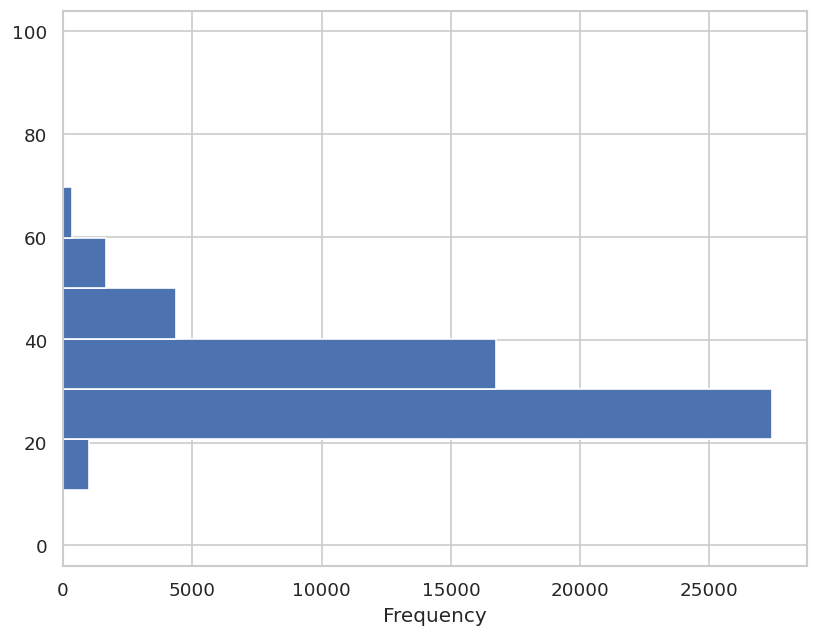

In [ ]:
df.Age.plot.hist(orientation="horizontal", bins=10, figsize=(8, 6))

👉 **Important**: To boost productivity, Pandas attempts to make plotting as painless as possible (unlike what one can expect with `matplotlib`). If not otherwise specified, Pandas makes the following two assumptions:
1. Index values are X-axis values.
2. A plot per-column (behavior differs with different plots).

Building on our example dealing with using ``groupby`` on experience level, we can now easily plot a bar graph showing the relationship between the average age and average years of experience for every experience level.

In [ ]:
df.groupby("ExpLevel")[["Age", "YearsCodePro"]].mean()

/tmp/ipykernel_1712/4267548119.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ExpLevel")[["Age", "YearsCodePro"]].mean()


,Age,YearsCodePro
ExpLevel,,
junior,25.780736,2.013150
experienced,28.815691,5.270310
senior,32.638793,9.080468
master,40.796309,18.120575


/tmp/ipykernel_1712/683131070.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ExpLevel")


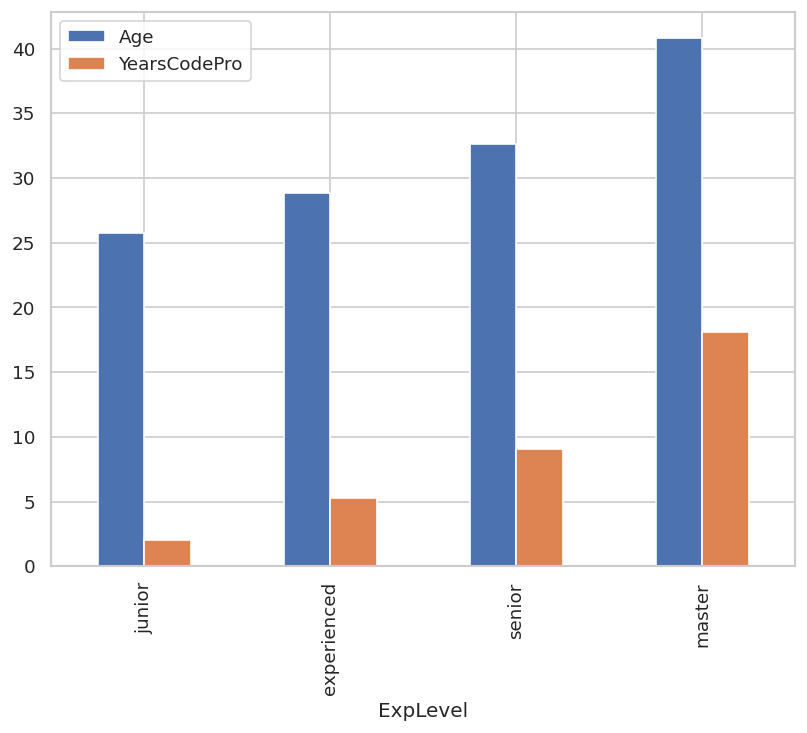

In [ ]:
(
    df.groupby("ExpLevel")
    [["Age", "YearsCodePro"]]
    .mean()
    .plot(kind="bar", figsize=(8, 6))  # Notice the .plot method
);    # <--- the semicolon prevents Jupyter from automatically rendering the return value's __repr__

/tmp/ipykernel_1712/1112636559.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("ExpLevel")


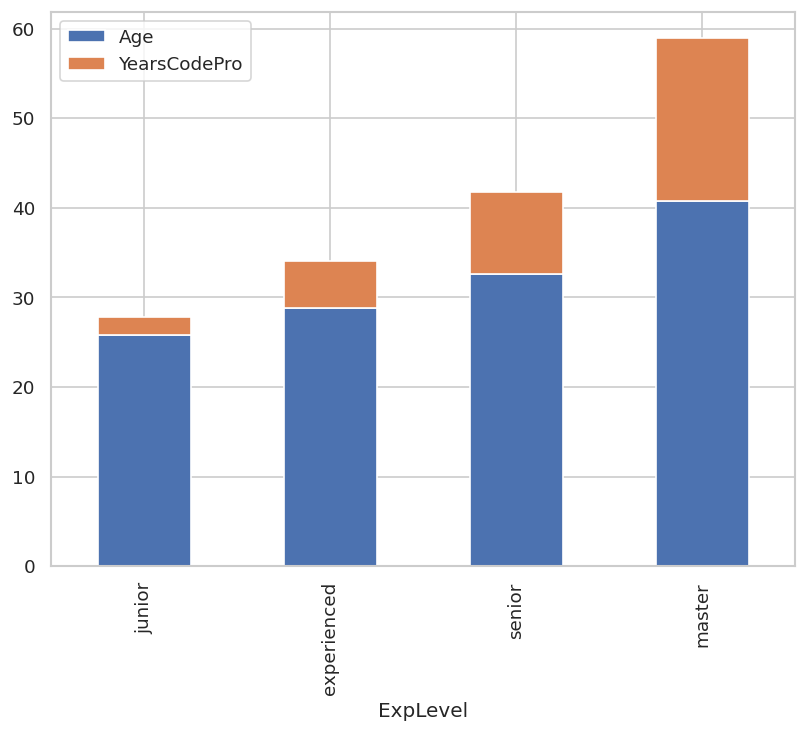

In [ ]:
(
    df.groupby("ExpLevel")
    [["Age", "YearsCodePro"]]
    .mean()
    .plot.bar(stacked=True, figsize=(8, 6))  # Notice the .plot method
);

Using `unstack` example:

In [ ]:
df[(df.Country == "Israel") & (df.Gender.isin(["Man", "Woman"]))].groupby(["Gender", df.Age // 10 * 10]) \
    .ConvertedComp.mean()

Gender  Age 
Man     10.0     45371.600000
        20.0     67590.086614
        30.0    104908.494585
        40.0    116957.725806
        50.0     98332.615385
        60.0     68948.000000
Woman   20.0     91478.250000
        30.0    129426.857143
        40.0    119586.000000
        50.0     32988.000000
Name: ConvertedComp, dtype: float64

In [ ]:
df[(df.Country == "Israel") & (df.Gender.isin(["Man", "Woman"]))].groupby(["Gender", df.Age // 10 * 10]) \
    .ConvertedComp.mean().unstack(0)

Gender,Man,Woman
Age,,
10.0,45371.600000,NaN
20.0,67590.086614,91478.250000
30.0,104908.494585,129426.857143
40.0,116957.725806,119586.000000
50.0,98332.615385,32988.000000
60.0,68948.000000,NaN


In [ ]:
# Compare salaries between men and women by age decade
(
    df
    [(df.Country == "Israel") & (df.Gender.isin(["Man", "Woman"]))]
    .groupby(["Gender", df.Age // 10 * 10])
    .ConvertedComp
    .mean()
    .unstack(0)
    .plot.bar()
)

If we wanted a scatter plot illustrating the relationship between age and years of experience:

In [ ]:
df.plot?

In [ ]:
df.plot(x="Age", y="YearsCodePro", kind="scatter", figsize=(8, 6));

Elegantly, when using the ``plot`` method, we can specify the ``x`` and ``y`` values simply by indicating the names of the corresponding columns in the DF.

Practically all arguments accepted by ``matplotlib`` plots, can be passed calling Pandas' wrapper methods.

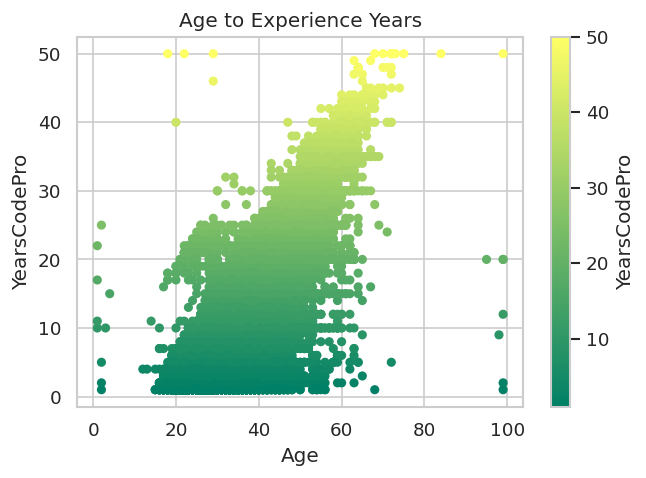

In [ ]:
df.plot.scatter(
    x="Age", y="YearsCodePro",
    c="YearsCodePro",
    title="Age to Experience Years",
    colormap="summer",
    figsize=(6,4)
);

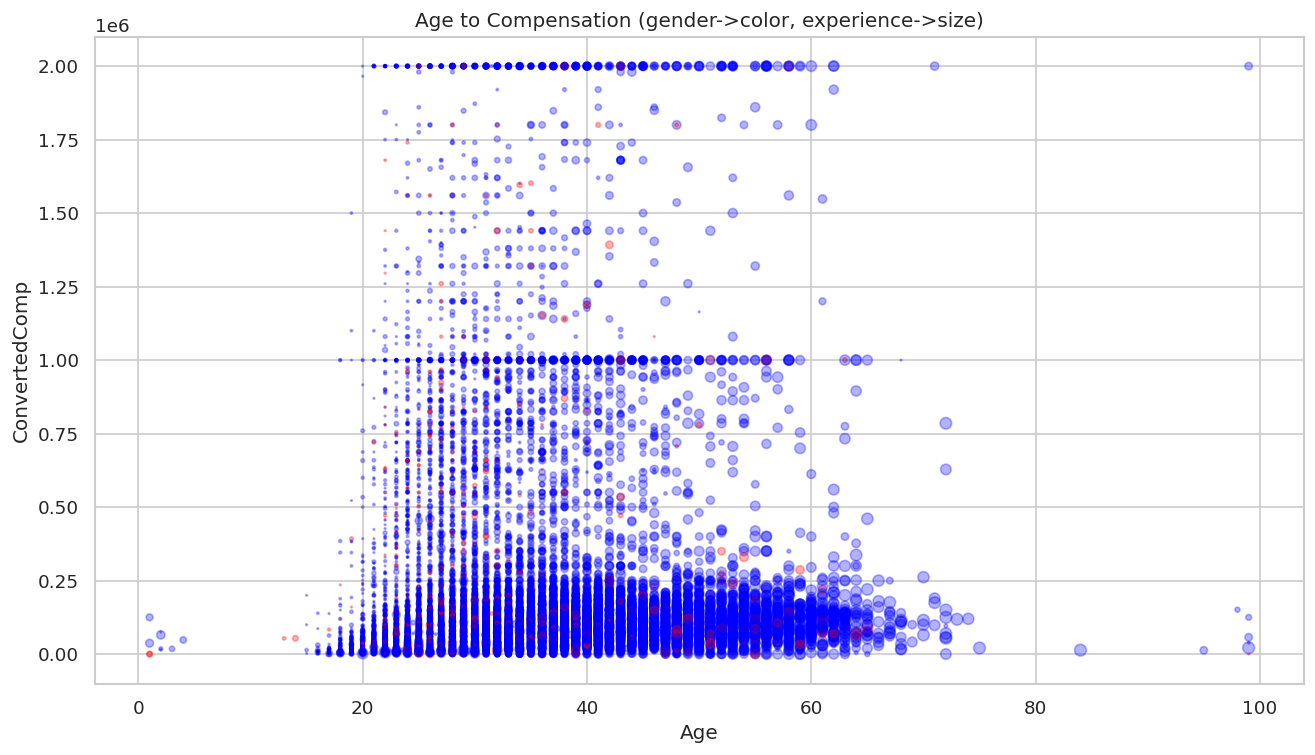

In [ ]:
(
    df
    [df.Gender.isin(["Man", "Woman"])]
    .replace({"Woman": "red", "Man": "blue"})
    .plot.scatter(
        x="Age", y="ConvertedComp",
        c="Gender", s="YearsCodePro",
        title="Age to Compensation (gender->color, experience->size)",
        # colormap="plasma",
        alpha=0.3,
        figsize=(13, 7)
    )
);

Too many dots overlapping on the scatter plot makes it impossible to assess density, i.e., identify what combinations of age and compensation are most common among respondents. A `hexbin` plot can help:

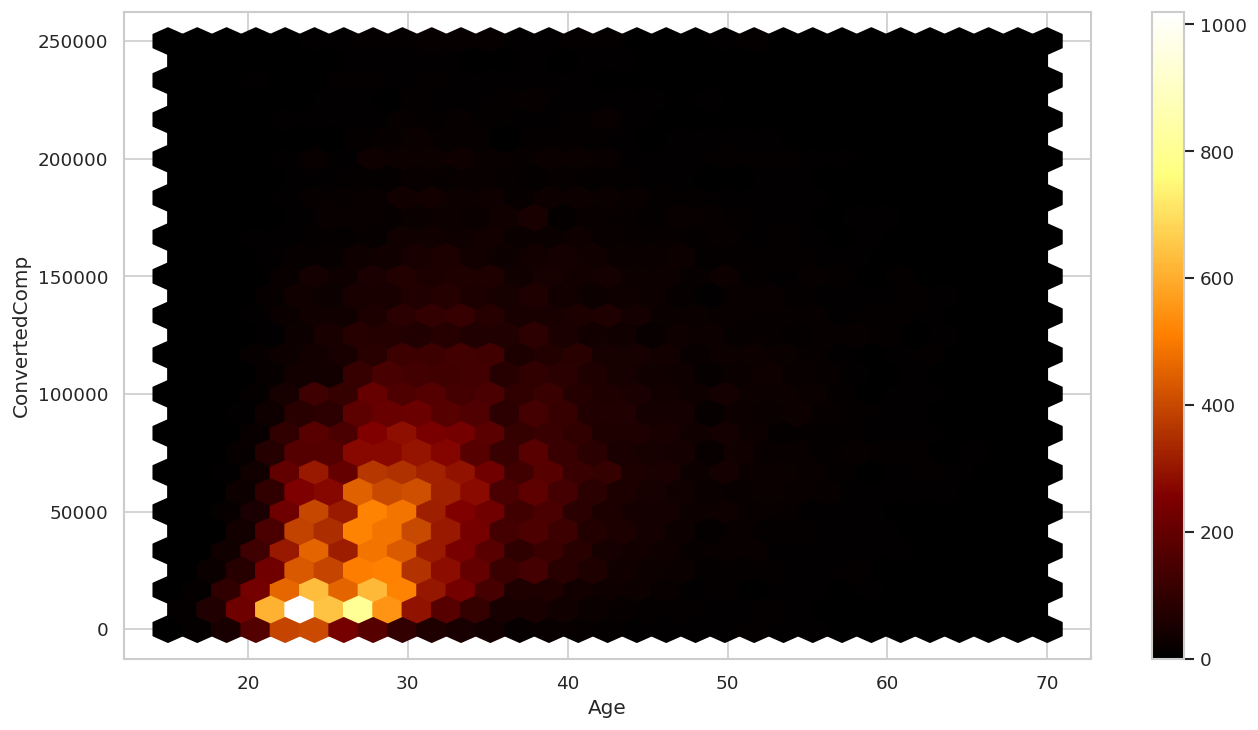

In [ ]:
(
    df
    [df.Gender.isin(["Man", "Woman"]) & (df.ConvertedComp <= 250_000) & (df.Age.between(15, 70))]
    .replace({"Woman": "red", "Man": "blue"})
    .plot.hexbin(
        x="Age", y="ConvertedComp",
        gridsize=(30, 15),
        colormap="afmhot",    # "gist_rainbow_r", "BuPu"
        figsize=(13, 7)
    )
);

### Seaborn

``Seaborn`` is a visualization library based on ``matplotlib``, providing higher-level graph and charts. In other words, it makes life easier producing more complex plots which would otherwise require fiddling with ``matplotlib``.
<br/>
Another nice benefit to using ``seaborn`` is that it integrates nicely with ``pandas``.

In [ ]:
df["AgeGroup"] = pd.cut(df.Age, bins=[0, 20, 30, 40, 50, 100], labels=["10s", "20s", "30s", "40s", "50+"])
df.head()

,Country,Age,Gender,YearsCodePro,OrgSize,WorkWeekHrs,ConvertedComp,LanguageWorkedWith,ExpLevel,AgeGroup
0,Thailand,28.0,Man,1,<500,40.0,8820.0,HTML/CSS,junior,20s
1,United States,22.0,Man,1,<500,80.0,61000.0,C;C++;C#;Python;SQL,junior,20s
2,New Zealand,23.0,Man,4,<20,32.0,95179.0,Bash/Shell/PowerShell;C#;HTML/CSS;JavaScript;P...,experienced,20s
3,United States,28.0,Man,8,<20,40.0,90000.0,Bash/Shell/PowerShell;HTML/CSS;JavaScript;PHP;...,senior,20s
4,Germany,31.0,Man,2,<500,40.0,57060.0,C++,junior,30s


Lets see some examples of useful ``seaborn`` graphs.

#### Countplot

A ``coutplot`` chart shows the counts of observations (variables) in each categorical bin using bars.

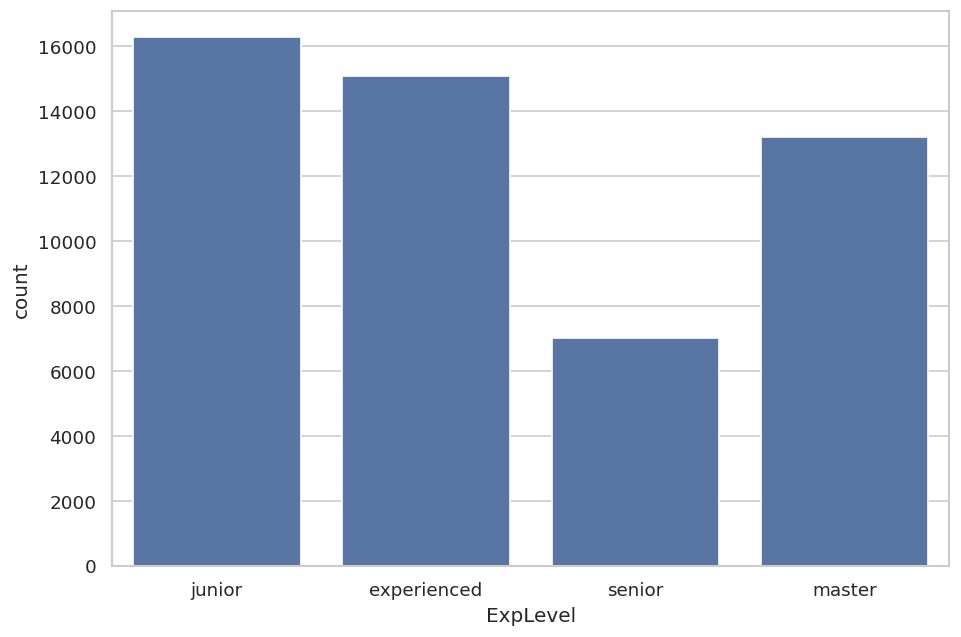

In [ ]:
sns.countplot(x="ExpLevel", data=df);

If we add the ``hue`` argument, we can have grouping criteria:

Text(0.5, 1.0, 'Age Group count by Experience Level')

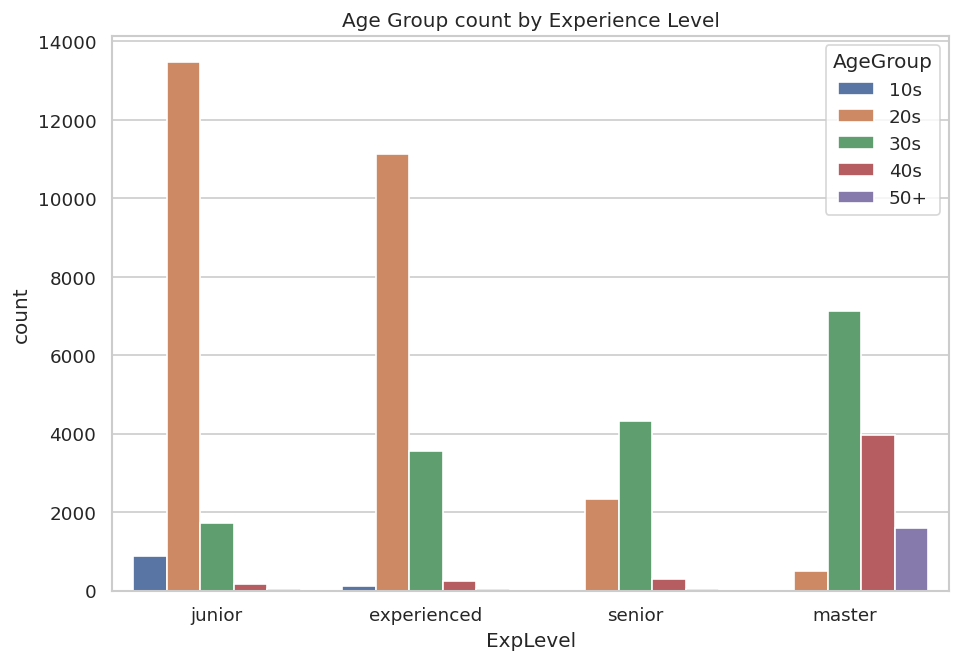

In [ ]:
ax = sns.countplot(x="ExpLevel", hue="AgeGroup", data=df)
ax.set_title("Age Group count by Experience Level")

#### Catplot

Multi-faceted count graphs are available with ``catplot``. The same graph can be produced for multiple categories represented as a certain variable's (column label) values.

In [ ]:
sns.catplot(x="ExpLevel", hue="AgeGroup", col="Gender", data=df, kind="count");

In [ ]:
sns.catplot(x="ExpLevel", hue="AgeGroup", col="Gender", data=df[df.Gender.isin(["Man", "Woman"])], kind="count");

#### Histplot

To chart a univariate distribution + histogram we can use ``histplot``:

In [ ]:
sns.histplot(df.Age, bins=10, kde=True);   # Kernel Density Estimation (KDE) / Probability Density Function (PDF)

#### Boxplot

A ``boxplot`` shows the distribution of values across quartiles, as well as suspected outliers and other information. They pack quite a lot of information into a single chart.

<div>
    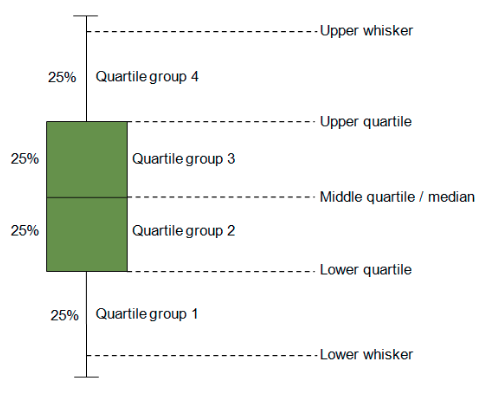
</div>
<br/>

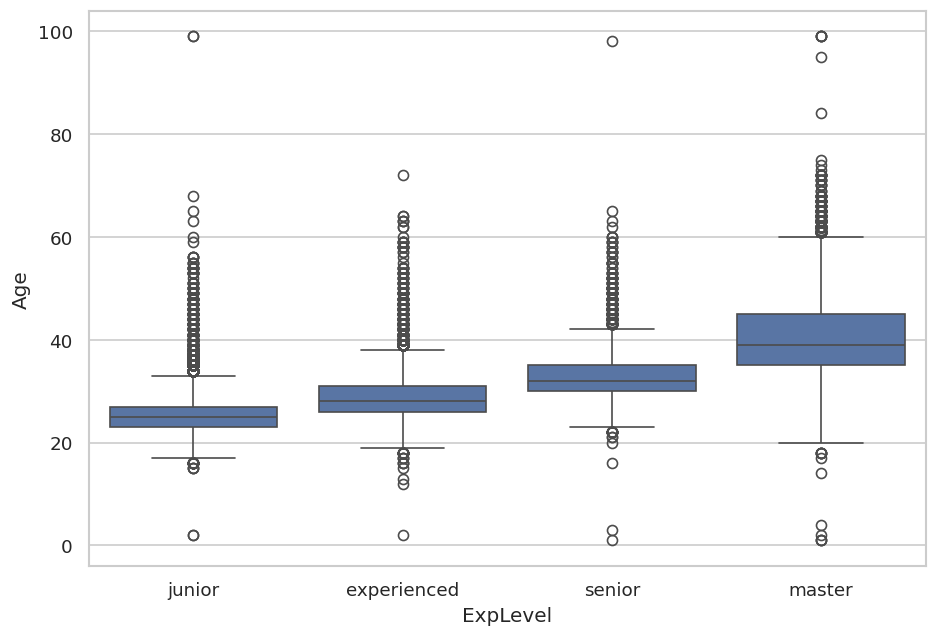

In [ ]:
sns.boxplot(x="ExpLevel", y="Age", data=df);

What are those diamond-shaped dots above and below the top and bottom whiskers? Those are suspected outlier datapoints calculated using the "1.5 IQR Rule" (IQR stands for Inter-Quantile Rule). The idea is that any datapoint above or below ``1.5 x (Q3 - Q1)`` may be considered an outlier. When applied, the lowest and highest datapoints which **do not fall outside** the "1.5 IQR Rule" become the new top and bottom whiskers. Any datapoint above or below the new whiskers is marked diamond - a suspected outlier.

On calculating outliers using the "1.5 IQR Rule":
https://www.youtube.com/watch?v=Cm_852R8JPw


#### Violinplot

A violinplot is similar to boxplot in purpose, but allows a deeper understanding of the data's density.

In [ ]:
sns.violinplot(x="ExpLevel", y="Age", data=df)

#### Heatmap

``heatmap`` charts help us visualize the correlation between any set of two variables. The junction between every two variables denotes the corellation between them, and the difference in color and intensity helps visualize the level of correlation.

In [ ]:
df_correlation = df.corr(numeric_only=True).round(2)
df_correlation

,Age,YearsCodePro,WorkWeekHrs,ConvertedComp
Age,1.00,0.83,0.02,0.11
YearsCodePro,0.83,1.00,0.01,0.10
WorkWeekHrs,0.02,0.01,1.00,0.01
ConvertedComp,0.11,0.10,0.01,1.00


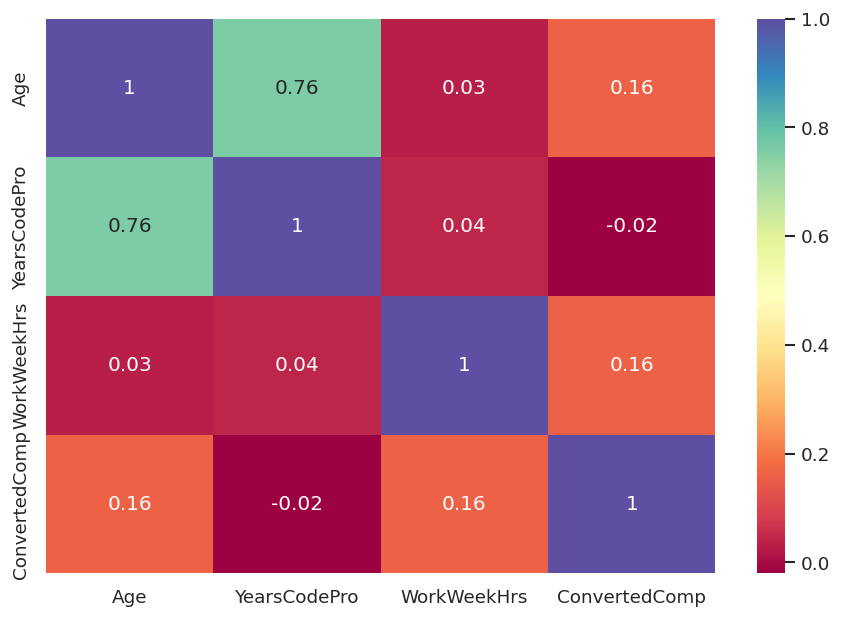

In [ ]:
sns.heatmap(
    data=df[(df.Country == "Israel") & (df.ConvertedComp <= 75000)].corr(numeric_only=True).round(2),
    annot=True, cmap="Spectral"
);


#### Pairplot

A ``pairplot`` shows the relationship between any two variables.
<br/>
The diagonal plots show the univariate distribution of the data for the variable in that column (line plot or histogram).

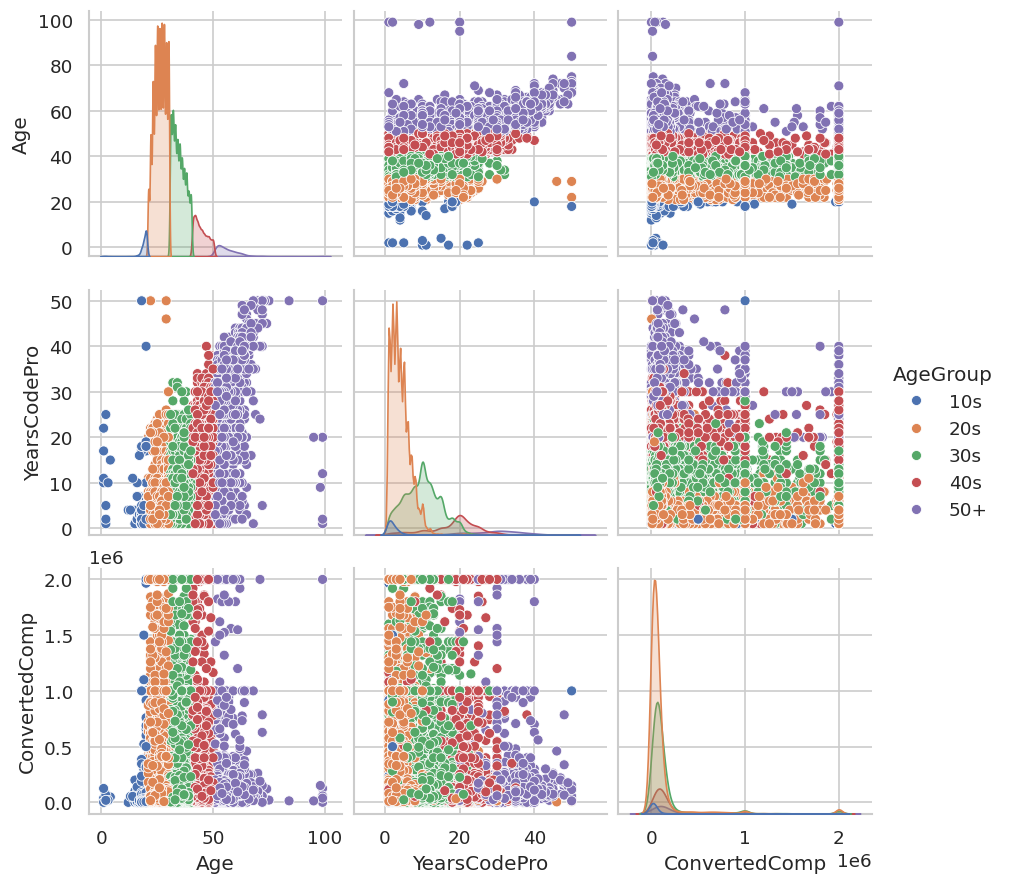

In [ ]:
sns.pairplot(df[["Age", "YearsCodePro", "ConvertedComp", "AgeGroup"]], hue="AgeGroup", kind="scatter", diag_kind="kde");

#### Regplot

A ``regplot`` plots data and a linear regression model fit.

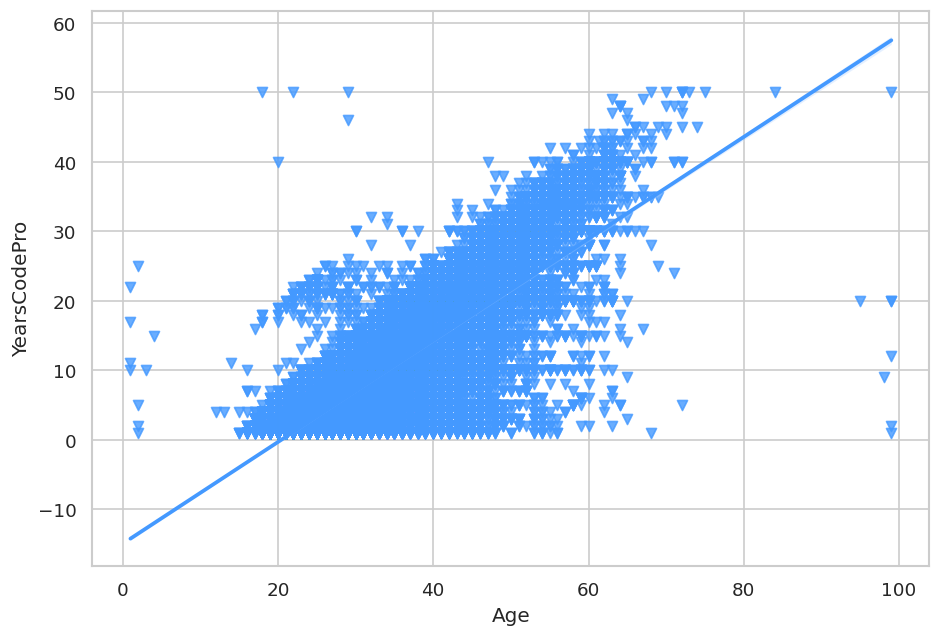

In [ ]:
sns.regplot(x="Age", y="YearsCodePro", data=df, marker="v", color="#4499ff");

### Plotly

A modern, interactive, plotting library.

https://plotly.com/python/

In [ ]:
# !pip install plotly

A couple of examples taken from the official site:

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

In [ ]:
import numpy as np
import pandas as pd

# Synthetic "elevation" grid (no internet needed)
x = np.linspace(-3, 3, 60)
y = np.linspace(-3, 3, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

z_data = pd.DataFrame(Z)
z_data.head()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,0.139708,0.238484,0.334796,0.427648,0.516082,0.599183,0.676093,0.746016,0.808231,0.862095,...,-0.862095,-0.808231,-0.746016,-0.676093,-0.599183,-0.516082,-0.427648,-0.334796,-0.238484,-0.139708
1,0.136964,0.233801,0.328221,0.419250,0.505947,0.587416,0.662816,0.731366,0.792360,0.845165,...,-0.845165,-0.792360,-0.731366,-0.662816,-0.587416,-0.505947,-0.419250,-0.328221,-0.233801,-0.136964
2,0.132805,0.226701,0.318255,0.406520,0.490585,0.569580,0.642690,0.709159,0.768300,0.819503,...,-0.819503,-0.768300,-0.709159,-0.642690,-0.569580,-0.490585,-0.406520,-0.318255,-0.226701,-0.132805
3,0.127274,0.217260,0.305000,0.389589,0.470153,0.545858,0.615923,0.679624,0.736302,0.785372,...,-0.785372,-0.736302,-0.679624,-0.615923,-0.545858,-0.470153,-0.389589,-0.305000,-0.217260,-0.127274
4,0.120428,0.205573,0.288594,0.368633,0.444863,0.516496,0.582792,0.643067,0.696696,0.743126,...,-0.743126,-0.696696,-0.643067,-0.582792,-0.516496,-0.444863,-0.368633,-0.288594,-0.205573,-0.120428


In [ ]:
fig = go.Figure(data=[go.Surface(z=z_data.values)])

fig.update_layout(title='Mt Bruno Elevation', autosize=False,
                  width=800, height=800,
                  margin=dict(l=65, r=50, b=65, t=90))
fig.show()

Another example. Try interacting with the slider and clicking on the "play" button.

In [ ]:
df_le = px.data.gapminder()
df_le.sample(5)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
1115,Nicaragua,Americas,2007,72.899,5675356,2749.320965,NIC,558
765,Israel,Asia,1997,78.269,5531387,20896.609240,ISR,376
1423,Spain,Europe,1987,76.900,38880702,15764.983130,ESP,724
962,Mauritania,Africa,1962,44.248,1146757,1055.896036,MRT,478
167,Botswana,Africa,2007,50.728,1639131,12569.851770,BWA,72


In [ ]:
px.scatter(
    df_le, x="gdpPercap", y="lifeExp",
    animation_frame="year", animation_group="country",
    size="pop", color="continent", hover_name="country",
    log_x=True, size_max=55,
    range_x=[100,100000], range_y=[25,90],
    height=450
)

## 🫵 Exercises (MovieLens)

These exercises use **movies.csv** and **ratings.csv**.

They intentionally combine skills from earlier modules:
- strings (parsing)
- containers
- flow control (small amount)
- functions
- and pandas fundamentals (indexing, groupby, merge, reshape)

In [ ]:
# TODO: your solution here

movies_with_year = None

movies_with_year

In [ ]:
# Solution
movies_with_year = movies.copy()

movies_with_year["year"] = (
    movies_with_year["title"]
    .str.extract(r"\((\d{4})\)$")[0]
    .astype("Int64")
)

movies_with_year["title_clean"] = (
    movies_with_year["title"]
    .str.replace(r"\s*\(\d{4}\)$", "", regex=True)
    .str.strip()
)

movies_with_year.sort_values(["year", "title_clean"]).head(10)

### Exercise 1 - top-rated movie per user (medium)

For each `userID`, find the movie(s) they rated the highest.

Return a DataFrame with columns:
- `userID`
- `title`
- `rating`

**Rules:**
- If a user has multiple movies tied for top rating, include all of them.
- Use pandas (no explicit for-loop needed).

**Hint:** use `groupby(...).transform("max")`.

In [ ]:
# your code here


#### Solution

In [ ]:
df_rm = df_ratings.merge(df_movies, on="movieID", how="left", validate="many_to_one")

max_per_user = df_rm.groupby("userID")["rating"].transform("max")
top_per_user = df_rm.loc[df_rm["rating"].eq(max_per_user), ["userID", "title", "rating"]].sort_values(["userID", "title"])

In [ ]:
top_per_user

### Exercise 2 (reshape + groupby) - best genres (medium)

Using `ratings_with_genre` (already built earlier):

1. Compute per-genre `n_ratings` and `avg_rating`
2. Keep genres with at least 2 ratings
3. Show the top 5 by `avg_rating` (desc), breaking ties by `n_ratings` (desc)

**Bonus**: round `avg_rating` to 2 decimals.

In [ ]:
# your code here


#### Solution

In [ ]:
best_genres = (
    ratings_with_genre
    .groupby("genre", as_index=False)
    .agg(n_ratings=("rating", "count"), avg_rating=("rating", "mean"))
)
best_genres = best_genres[best_genres["n_ratings"] >= 2]
best_genres = best_genres.sort_values(["avg_rating", "n_ratings"], ascending=[False, False]).head(5)
best_genres.assign(avg_rating=best_genres["avg_rating"].round(2))

### Exercise 3 (wide ↔ long) - User × Movie matrix and back (advanced)

1. Create a pivot table with:
   - index = `userID`
   - columns = `movieID`
   - values = `rating`
2. Melt it back to long format with columns: `userID`, `movieID`, `rating`
3. Drop NaNs and sort by `userID`, then `movieID`.

**Goal:** you should get (roughly) the same rows as the original `ratings` table (ordering can differ).

In [ ]:
# your code here

ratings_matrix = None
ratings_long = None

ratings_matrix, ratings_long.head() if ratings_long is not None else None

#### Solution

In [ ]:
ratings_matrix = df_ratings.pivot_table(index="userID", columns="movieID", values="rating", aggfunc="mean")

In [ ]:
ratings_matrix.head()

In [ ]:
ratings_long = (
    ratings_matrix
    .reset_index()
    .melt(id_vars=["userID"], var_name="movieID", value_name="rating")
    .dropna(subset=["rating"])
    .sort_values(["userID", "movieID"])
    .reset_index(drop=True)
)

In [ ]:
ratings_long.head(10)

### Exercise 4 (SQL ↔ pandas) - average rating per user in SQL (medium)

Using the SQL connection (`sql_con`) created earlier, write a query that returns:

- `userID`
- `n_ratings`
- `avg_rating`

Order by `avg_rating` desc then `n_ratings` desc.

In [ ]:
# your code here


In [ ]:
sql_user = """
SELECT  userID,
        COUNT(*) AS n_ratings,
        ROUND(AVG(rating), 3) AS avg_rating
FROM ratings
GROUP BY userID
ORDER BY avg_rating DESC, n_ratings DESC, userID ASC
"""

In [ ]:
pd.read_sql_query(sql_user, sql_con)

### Exercise 5 - a reusable leaderboard function (advanced)

Write a function:

```python
def movie_leaderboard(ratings: pd.DataFrame,
                      movies: pd.DataFrame,
                      *,
                      min_ratings: int = 2,
                      round_to: int = 3) -> pd.DataFrame:
    ...
```

Requirements:
- Merge ratings with movies (on `movieID`)
- Compute `n_ratings` and `avg_rating` per `title`
- Filter by `min_ratings`
- Sort by `avg_rating` desc, then `n_ratings` desc, then `title` asc
- Round `avg_rating` to `round_to` decimals
- Return the final DataFrame

This ties together:
- functions + keyword-only args + defaults
- merge + groupby + agg + sort_values

In [ ]:
# your code here

def movie_leaderboard(ratings: pd.DataFrame, movies: pd.DataFrame, *, min_ratings: int = 2, round_to: int = 3) -> pd.DataFrame:
    ...

movie_leaderboard(df_ratings, df_movies)

#### Solution

In [ ]:
def movie_leaderboard(ratings: pd.DataFrame, movies: pd.DataFrame, *, min_ratings: int = 2, round_to: int = 3) -> pd.DataFrame:

    df_rm = ratings.merge(movies, on="movieID", how="left", validate="many_to_one")
    out = (
        df_rm
        .groupby("title", as_index=False)
        .agg(n_ratings=("rating", "count"), avg_rating=("rating", "mean"))
    )
    out = out[out["n_ratings"] >= min_ratings]
    out = out.sort_values(["avg_rating", "n_ratings", "title"], ascending=[False, False, True]).reset_index(drop=True)
    out["avg_rating"] = out["avg_rating"].round(round_to)

    return out

In [ ]:
movie_leaderboard(df_ratings, df_movies)

### Exercise 6 - ETL: validate + quarantine + chunked ingest (hard)

Data engineering often means: **ingest → validate → quarantine bad rows → publish clean outputs**.

Task:

1. Create a small *dirty* version of `ratings` by injecting a few bad rows:
   - a rating outside `[0.5, 5.0]`
   - a missing `movieID`
2. Implement a function:

```python
def validate_ratings_chunk(chunk: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (good_rows, bad_rows)."""
```

Rules:
- `movieID` and `userID` must be non-null
- `rating` must be between 0.5 and 5.0 (inclusive)

3. Simulate streaming the dirty data in chunks (use slicing with `CHUNK_SIZE`) and build:
- `ratings_clean` (all good rows)
- `ratings_quarantine` (all bad rows, with an added column `error_reason`)

4. Publish:
- `ratings_clean` → SQLite table `fact_rating_clean`
- `ratings_quarantine` → CSV file in `OUTPUT_DIR`

In [ ]:
ratings_dirty = df_ratings.copy()

# Inject a couple of issues
if len(ratings_dirty) >= 3:
    ratings_dirty.loc[0, "rating"] = 99          # out of range
    ratings_dirty.loc[1, "movieID"] = None       # missing key
    ratings_dirty.loc[2, "userID"] = None        # missing key


def validate_ratings_chunk(chunk: pd.DataFrame):
    # return good_rows, bad_rows
    # your code here    <------------------------- !
    ...


#
ratings_clean_parts = []
ratings_bad_parts = []

CHUNK_SIZE = 5000

for start in range(0, len(ratings_dirty), CHUNK_SIZE):
    chunk = ratings_dirty.iloc[start:start+CHUNK_SIZE].copy()
    good, bad = validate_ratings_chunk(chunk)
    ratings_clean_parts.append(good)
    ratings_bad_parts.append(bad)

ratings_clean = pd.concat(ratings_clean_parts, ignore_index=True)
ratings_quarantine = pd.concat(ratings_bad_parts, ignore_index=True)

In [ ]:
ratings_clean.head()

In [ ]:
ratings_quarantine.head()

#### Solution

In [ ]:
ratings_dirty = df_ratings.copy()

if len(ratings_dirty) >= 3:
    ratings_dirty.loc[0, "rating"] = 99
    ratings_dirty.loc[1, "movieID"] = None
    ratings_dirty.loc[2, "userID"] = None


def validate_ratings_chunk(chunk: pd.DataFrame):
    chunk = chunk.copy()
    reasons = pd.Series("", index=chunk.index, dtype="object")

    missing_movie = chunk["movieID"].isna()
    missing_user = chunk["userID"].isna()
    if missing_movie.any():
        reasons[missing_movie] += "missing_movieID;"
    if missing_user.any():
        reasons[missing_user] += "missing_userID;"

    bad_rating = ~(chunk["rating"].between(0.5, 5.0))
    if bad_rating.any():
        reasons[bad_rating] += "rating_out_of_range;"

    bad_mask = reasons != ""
    bad = chunk[bad_mask].copy()
    bad["error_reason"] = reasons[bad_mask].str.rstrip(";")

    good = chunk[~bad_mask].copy()

    return good, bad

In [ ]:
ratings_clean_parts = []
ratings_bad_parts = []

CHUNK_SIZE = 5000

for start in range(0, len(ratings_dirty), CHUNK_SIZE):
    chunk = ratings_dirty.iloc[start:start+CHUNK_SIZE].copy()
    good, bad = validate_ratings_chunk(chunk)
    ratings_clean_parts.append(good)
    ratings_bad_parts.append(bad)

ratings_clean = pd.concat(ratings_clean_parts, ignore_index=True)
ratings_quarantine = pd.concat(ratings_bad_parts, ignore_index=True)

In [ ]:
# Publish
ratings_clean.to_sql("fact_rating_clean", sql_con, if_exists="replace", index=False)
quarantine_path = OUTPUT_DIR / "ratings_quarantine.csv"
ratings_quarantine.to_csv(quarantine_path, index=False)

In [ ]:
ratings_clean.head()

In [ ]:
ratings_quarantine.head()

In [ ]:
quarantine_path.resolve()

### Exercise 7 - build a tiny star schema (dimension/fact) in SQLite (hard)

**Goal**: model MovieLens data like a warehouse.

Build and publish:
- `dim_movie(movieID, title, year)`
- `dim_genre(genre_id, genre)`  (surrogate key)
- `bridge_movie_genre(movieID, genre_id)`  (many-to-many)
- `fact_rating(userID, movieID, rating, timestamp)`

Then answer:
1) In **SQL**: average rating by genre, keep only genres with `n_ratings >= 50`  
2) In **pandas**: compute the same result and compare

**Hints**:
- Extract year from `title` using a regex (you did in Exercise 1)
- Use `movies_by_genre` (already created earlier) to build the bridge table
- Use `to_sql(..., if_exists="replace")` for idempotent reruns

In [ ]:
# your code here

# 1) dim_movie
# 2) dim_genre + bridge_movie_genre
# 3) fact_rating
# 4) SQL query: avg rating by genre with min sample size
# 5) pandas equivalent and compare

#### Solution

In [ ]:
# 1) dim_movie

dim_movie = df_movies.copy()
dim_movie["year"] = dim_movie["title"].str.extract(r"\((\d{4})\)")[0].astype("Int64")
dim_movie = dim_movie[["movieID", "title", "year"]]

In [ ]:
# 2) dim_genre + bridge

dim_genre = (
    movies_by_genre[["genre"]]
    .drop_duplicates()
    .sort_values("genre")
    .reset_index(drop=True)
)
dim_genre["genre_id"] = dim_genre.index + 1
dim_genre = dim_genre[["genre_id", "genre"]]

bridge_movie_genre = movies_by_genre.merge(dim_genre, on="genre", how="left")[["movieID", "genre_id"]]

In [ ]:
# 3) fact_rating

fact_rating = df_ratings[["userID", "movieID", "rating", "timestamp"]].copy()

# publish

dim_movie.to_sql("dim_movie", sql_con, if_exists="replace", index=False)
dim_genre.to_sql("dim_genre", sql_con, if_exists="replace", index=False)
bridge_movie_genre.to_sql("bridge_movie_genre", sql_con, if_exists="replace", index=False)
fact_rating.to_sql("fact_rating", sql_con, if_exists="replace", index=False)

In [ ]:
# 4) SQL: avg rating by genre

sql = """
SELECT g.genre,
       COUNT(*) AS n_ratings,
       ROUND(AVG(f.rating), 3) AS avg_rating
FROM fact_rating f
JOIN bridge_movie_genre bg ON f.movieID = bg.movieID
JOIN dim_genre g ON bg.genre_id = g.genre_id
GROUP BY g.genre
HAVING COUNT(*) >= 50
ORDER BY avg_rating DESC, n_ratings DESC, g.genre ASC
"""
sql_genre = pd.read_sql_query(sql, sql_con)

In [ ]:
# 5) pandas equivalent

tmp = ratings_with_genre.copy()
tmp["genre"] = tmp["genre"].fillna("UNKNOWN")

pd_genre = (
    tmp
    .groupby("genre", as_index=False)
    .agg(n_ratings=("rating", "count"), avg_rating=("rating", "mean"))
)
pd_genre = pd_genre[pd_genre["n_ratings"] >= 50].copy()
pd_genre["avg_rating"] = pd_genre["avg_rating"].round(3)
pd_genre = pd_genre.sort_values(["avg_rating", "n_ratings", "genre"], ascending=[False, False, True]).reset_index(drop=True)

In [ ]:
sql_genre.head()

In [ ]:
pd_genre.head()

<hr/>